In [4]:
# --- STEP 1: PYTHON 3.12 PYOPENGL SYSTEM CRASH PATCH ---
# This dynamically intercepts Python 3.12 ctypes calls and maps them to standard 
# pointer types, completely bypassing PyOpenGL's array-handler registry bugs.
print("Applying Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    from OpenGL.arrays import ctypesarrays
    
    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    CStructType = type(ctypes.c_int)
    
    orig_get_type_handler = arraydatatype.ArrayDatatype.get_type_handler
    
    def patched_get_type_handler(typ, *args, **kwargs):
        if typ is CArgObject:
            return orig_get_type_handler(ctypes.c_void_p)
        if isinstance(typ, CStructType) or typ is CStructType:
            return orig_get_type_handler(ctypes.c_void_p)
        return orig_get_type_handler(typ, *args, **kwargs)
        
    arraydatatype.ArrayDatatype.get_type_handler = patched_get_type_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import os
import math
import time
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """
    Downloads Esri satellite tiles matching the DEM boundaries,
    utilizing a robust 3-attempt retry loop with exponential backoff 
    and request throttling to prevent rate-limit blocks.
    """
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)
    
    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")
    
    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            
            # --- ROBUST RETRY LOOP (3 ATTIDUDES WITH BACKOFF) ---
            tile_downloaded = False
            for attempt in range(3):
                try:
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=7) as resp:
                        tile_img = Image.open(io.BytesIO(resp.read()))
                        stitched_image.paste(tile_img, (i * 256, j * 256))
                        tile_downloaded = True
                        success_count += 1
                        break  # Break out of the retry loop if successful
                except Exception as e:
                    # Exponential backoff: wait 1s, then 2s, then 4s before retrying
                    wait_time = 2 ** attempt
                    print(f"  [Attempt {attempt+1}/3 failed for tile ({x},{y})]: {e}. Retrying in {wait_time}s...")
                    time.sleep(wait_time)
            
            # If all 3 attempts fail, paste the default moraine fallback
            if not tile_downloaded:
                print(f"  [CRITICAL: Failed to download tile ({x},{y}) after 3 attempts. Pasting fallback.]")
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))
            
            # Throttling: brief sleep (100ms) to respect Esri's servers and prevent IP bans
            time.sleep(0.1)
                
    print(f"Successfully compiled {success_count}/{total_tiles} tiles.")
    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)
    
    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon
    
# 1. Load active DEM and detect CRS / Bounds dynamically
print("Loading DEM and detecting georeferencing...")
stride = 3  

with rasterio.open("data/dem.tif") as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height
    
    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data = np.flipud(dem_data)
        
    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy (Instant - under 1 millisecond)
print("Dynamically cropping 110km x 110km local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]

crop_size_x = 110000.0  
crop_size_y = 110000.0

crop_min_x = center_x - crop_size_x / 2.0
crop_max_x = center_x + crop_size_x / 2.0
crop_min_y = center_y - crop_size_y / 2.0
crop_max_y = center_y + crop_size_y / 2.0

x_mask = (raw_xs >= crop_min_x) & (raw_xs <= crop_max_x)
y_mask = (raw_ys >= crop_min_y) & (raw_ys <= crop_max_y)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]
dem_data_cropped = dem_data[y_mask][:, x_mask]

# STRIDE 2: Double the mesh resolution for sharp terrain faces
stride = 2  
dem_data_final = dem_data_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

# Generate 3D Vertices
X, Y = np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))
vertices = np.column_stack((X.ravel(), Y.ravel(), dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))
print(f"Mesh generated with {faces.shape[0]:,} triangles (60m spacing).")

# 3. Dynamic GPS Coordinate Transformation
print("Dynamically calculating GPS bounding box...")
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])

print(f"Cropped GPS Box: {gps_min_lat:.5f}°N, {gps_min_lon:.5f}°E to {gps_max_lat:.5f}°N, {gps_max_lon:.5f}°E")

# Transform cropped vertices to GPS for texturing
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Check for Cached Satellite Texture with Dynamic Coordinates Validation
texture_img_path = "data/satellite_texture_cropped.png"
bounds_path = "data/satellite_texture_bounds_cropped.npz"

cache_valid = False
if os.path.exists(texture_img_path) and os.path.exists(bounds_path):
    bounds_data = np.load(bounds_path)
    if (abs(float(bounds_data['min_lat']) - gps_min_lat) < 0.01 and
        abs(float(bounds_data['max_lat']) - gps_max_lat) < 0.01 and
        abs(float(bounds_data['min_lon']) - gps_min_lon) < 0.01 and
        abs(float(bounds_data['max_lon']) - gps_max_lon) < 0.01):
        cache_valid = True

if cache_valid:
    print("Loading cached satellite texture and bounds from local disk...")
    sat_image = Image.open(texture_img_path)
    bounds_data = np.load(bounds_path)
    img_min_lat = float(bounds_data['min_lat'])
    img_max_lat = float(bounds_data['max_lat'])
    img_min_lon = float(bounds_data['min_lon'])
    img_max_lon = float(bounds_data['max_lon'])
else:
    sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
        gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
    )
    print("Caching satellite texture and bounds locally for future runs...")
    os.makedirs("data", exist_ok=True)
    sat_image.save(texture_img_path)
    np.savez(bounds_path, 
             min_lat=img_min_lat, max_lat=img_max_lat, 
             min_lon=img_min_lon, max_lon=img_max_lon)

# sat_array = np.array(sat_image)
# stitched_h, stitched_w, _ = sat_array.shape

# # 5. Perform Planar UV Mapping
# print("Mapping satellite photography onto 3D vertices...")
# u = (lon_v - img_min_lon) / (img_max_lon - img_min_lon)
# v = (lat_v - img_min_lat) / (img_max_lat - img_min_lat)

# u = np.clip(u, 0.0, 1.0)
# v = np.clip(v, 0.0, 1.0)

# # Build UV coordinate arrays
# uv = np.column_stack((u, v))

# # --- ADVANCED GPU PBR TEXTURE ENGINE (Memory-Optimized with float32) ---
# print("Generating high-fidelity PBR texture maps...")
# base_color_tex = pyrender.Texture(source=sat_image, source_channels='RGB')

# # B. Procedural Normal Map (Memory-Optimized with float32 & organic noise)
# # This completely eliminates repeating geometric lines from the normal maps.
# np.random.seed(101)
# noise_raw = np.random.uniform(-1.0, 1.0, size=(stitched_h, stitched_w)).astype(np.float32)

# # Fast 3x3 local box blur in pure NumPy to cluster the noise into organic rock grains
# padded_noise = np.pad(noise_raw, 1, mode='edge')
# smoothed_noise = (padded_noise[:-2, :-2] + padded_noise[1:-1, :-2] + padded_noise[2:, :-2] +
#                   padded_noise[:-2, 1:-1] + padded_noise[1:-1, 1:-1] + padded_noise[2:, 1:-1] +
#                   padded_noise[:-2, 2:] + padded_noise[1:-1, 2:] + padded_noise[2:, 2:]) / 9.0

# # Calculate normal vectors via Sobel derivatives
# dy, dx = np.gradient(smoothed_noise)
# bump_strength = 2.5
# nx = -dx * bump_strength
# ny = -dy * bump_strength
# nz = np.ones_like(nx, dtype=np.float32)
# norm = np.sqrt(nx**2 + ny**2 + nz**2)
# nx, ny, nz = nx/norm, ny/norm, nz/norm

# # Encode to [0, 255] RGB space (standard normal map encoding)
# normal_map = np.stack((
#     ((nx + 1.0) / 2.0 * 255),
#     ((ny + 1.0) / 2.0 * 255),
#     ((nz + 1.0) / 2.0 * 255)
# ), axis=-1).astype(np.uint8)

# normal_img = Image.fromarray(normal_map)
# normal_tex = pyrender.Texture(source=normal_img, source_channels='RGB')

# # C. Procedural Metallic-Roughness Map
# snow_mask = (sat_array[:, :, 0] > 180) & (sat_array[:, :, 1] > 180) & (sat_array[:, :, 2] > 180)
# mr_array = np.zeros((stitched_h, stitched_w, 3), dtype=np.uint8)
# mr_array[:, :, 1] = np.where(snow_mask, int(0.15 * 255), int(0.95 * 255)).astype(np.uint8)
# mr_array[:, :, 2] = 0 # Non-metallic

# mr_img = Image.fromarray(mr_array)
# mr_mr_tex = pyrender.Texture(source=mr_img, source_channels='RGB')

# pbr_material = pyrender.MetallicRoughnessMaterial(
#     baseColorTexture=base_color_tex,
#     normalTexture=normal_tex,
#     metallicRoughnessTexture=mr_mr_tex,
#     roughnessFactor=1.0,
#     metallicFactor=1.0
# )

# # 6. CRITICAL FIX: Smooth 3D Vertex Normals from Blurred DEM
# # This completely eliminates the dark "wireframe" lines from the slope map.
# print("Smoothing DEM and calculating continuous 3D vertex normals...")
# padded_dem = np.pad(dem_data_final, 1, mode='edge')
# smoothed_dem = (padded_dem[:-2, :-2] + padded_dem[1:-1, :-2] + padded_dem[2:, :-2] +
#                 padded_dem[:-2, 1:-1] + padded_dem[1:-1, 1:-1] + padded_dem[2:, 1:-1] +
#                 padded_dem[:-2, 2:] + padded_dem[1:-1, 2:] + padded_dem[2:, 2:]) / 9.0

# dy_g, dx_g = np.gradient(smoothed_dem, (pixel_height * stride), (pixel_width * stride))
# nz_g = np.ones_like(dx_g, dtype=np.float32)
# norm_g = np.sqrt(dx_g**2 + dy_g**2 + 1.0)

# # Reshape normals to match vertex length (N, 3)
# vertex_normals = np.column_stack((
#     -dx_g.ravel() / norm_g.ravel(),
#     -dy_g.ravel() / norm_g.ravel(),
#     nz_g.ravel() / norm_g.ravel()
# )).astype(np.float32)

# # Create the final GPU Primitive with direct attributes mapping
# primitive = pyrender.Primitive(
#     positions=vertices,
#     normals=vertex_normals,
#     texcoord_0=uv,
#     indices=faces,
#     material=pbr_material,
#     mode=pyrender.GLTF.TRIANGLES
# )
# pyrender_mesh = pyrender.Mesh(primitives=[primitive])

# # 7. Setup Scene & Calibrated Daylight Shading
# print("Configuring calibrated daylight model...")
# scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25]) # Soft blue skylight fill
# scene.add(pyrender_mesh)

# sun_color = [1.0, 1.0, 0.95] 
# sun_intensity = 2.8          
# sun_pose = np.array([
#     [1.0,  0.0,  0.0, 0.0],
#     [0.0,  0.707, -0.707, 0.0],
#     [0.0,  0.707,  0.707, 0.0],
#     [0.0,  0.0,  0.0, 1.0]
# ], dtype=np.float32)

# sun_light = pyrender.DirectionalLight(color=sun_color, intensity=sun_intensity)
# scene.add(sun_light, pose=sun_pose)

# # --- LOOK-AT CAMERA POSITIONING ---
# print("Calculating camera pose focused on highest peak...")
# peak_idx = np.argmax(vertices[:, 2])
# peak_x, peak_y, peak_z = vertices[peak_idx]

# eye = np.array([peak_x - 10000, peak_y - 12000, peak_z + 3000], dtype=np.float32)
# target = np.array([peak_x, peak_y, peak_z], dtype=np.float32)

# forward = target - eye
# forward /= np.linalg.norm(forward)

# up_global = np.array([0.0, 0.0, 1.0], dtype=np.float32)
# right = np.cross(forward, up_global)
# right /= np.linalg.norm(right)

# up_camera = np.cross(right, forward)
# up_camera /= np.linalg.norm(up_camera)

# cam_pose = np.eye(4, dtype=np.float32)
# cam_pose[:3, 0] = right
# cam_pose[:3, 1] = up_camera
# cam_pose[:3, 2] = -forward
# cam_pose[:3, 3] = eye

# camera = pyrender.PerspectiveCamera(yfov=np.radians(40.0), aspectRatio=1.5, znear=10.0, zfar=200000.0)
# scene.add(camera, pose=cam_pose)

# # 8. Offscreen GPU Rendering Pass (SSAA)
# print("Rendering baseline geometry on GPU with 2x SSAA...")
# img_w, img_h = 2160, 1440
# renderer = pyrender.OffscreenRenderer(img_w, img_h)
# raw_color, depth = renderer.render(scene)
# renderer.delete()

# sky_mask = depth == 0.0

# # 9. Advanced Sky background (fBm Clouds + Glowing Sun)
# print("Generating sky background with glowing sun and non-periodic clouds...")
# sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
# y_idx_sky, x_idx_sky = np.indices((img_h, img_w))

# y_factor = (y_idx_sky / img_h)[:, :, np.newaxis]
# sky_top = np.array([10.0, 45.0, 120.0])
# sky_bottom = np.array([165.0, 205.0, 240.0])
# sky_background = (1.0 - y_factor**1.2) * sky_top + (y_factor**1.2) * sky_bottom

# # Configure sun position dynamically
# sun_x = int(img_w * 0.65)
# sun_y = int(img_h * 0.20)
# dist_to_sun = np.sqrt((x_idx_sky - sun_x)**2 + (y_idx_sky - sun_y)**2)

# # Soft sun glow
# sun_glow = np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis]
# sun_glow_color = np.array([255.0, 245.0, 215.0])
# sky_background += sun_glow * sun_glow_color * 0.90

# sun_core = (dist_to_sun < 15.0)[:, :, np.newaxis]
# sky_background = np.where(sun_core, np.array([255.0, 255.0, 255.0]), sky_background)

# # Procedural clouds (fBm)
# np.random.seed(42)
# l1_raw = np.random.uniform(0, 1, (8, 12))
# l1 = np.array(Image.fromarray((l1_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# l2_raw = np.random.uniform(0, 1, (24, 36))
# l2 = np.array(Image.fromarray((l2_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# l3_raw = np.random.uniform(0, 1, (72, 108))
# l3 = np.array(Image.fromarray((l3_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# cloud_noise = l1 * 0.55 + l2 * 0.32 + l3 * 0.13
# ny_sky = y_idx_sky / img_h
# cloud_height_attenuation = np.sin(ny_sky * np.pi)
# cloud_density = np.clip((cloud_noise - 0.44) * 3.2, 0.0, 1.0) * cloud_height_attenuation * 0.28
# cloud_density = cloud_density[:, :, np.newaxis]

# cloud_color = np.array([245.0, 248.0, 252.0])
# sky_final = (1.0 - cloud_density) * sky_background + cloud_density * cloud_color
# sky_background_final = np.clip(sky_final, 0, 255).astype(np.uint8)

# # 10. Apply Crisp Mountain Haze
# fog_color = [165, 185, 210]  
# fog_density = 0.000025

# extinction = np.exp(-fog_density * depth)
# extinction = np.clip(extinction, 0.0, 1.0)[:, :, np.newaxis]
# fog_rgb = np.array(fog_color, dtype=np.float32)

# processed_image = (1.0 - extinction) * fog_rgb + extinction * raw_color.astype(np.float32)
# processed_image[sky_mask] = sky_background_final[sky_mask]
# processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# # 11. Post-Processing Lens Effects
# print("Applying lens and camera post-processing...")
# # Wide-Angle Vignetting
# cy, cx = img_h / 2.0, img_w / 2.0
# y_grid, x_grid = np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')
# norm_dist_to_center = np.sqrt(((x_grid - cx) / cx)**2 + ((y_grid - cy) / cy)**2)
# vignette_mask = np.clip(1.0 - 0.35 * (norm_dist_to_center ** 2), 0.0, 1.0)[:, :, np.newaxis]

# # Radial Chromatic Aberration (Fringing)
# img_pil = Image.fromarray(processed_image)

# r_chan = img_pil.getchannel('R')
# r_w, r_h = int(img_w * 1.006), int(img_h * 1.006)
# r_resized = r_chan.resize((r_w, r_h), Image.Resampling.LANCZOS)
# left_r, top_r = (r_w - img_w) // 2, (r_h - img_h) // 2
# r_final = r_resized.crop((left_r, top_r, left_r + img_w, top_r + img_h))

# g_final = img_pil.getchannel('G')

# b_chan = img_pil.getchannel('B')
# b_w, b_h = int(img_w * 0.994), int(img_h * 0.994)
# b_resized = b_chan.resize((b_w, b_h), Image.Resampling.LANCZOS)
# b_final = Image.new('L', (img_w, img_h), 0)
# left_b, top_b = (img_w - b_w) // 2, (img_h - b_h) // 2
# b_final.paste(b_resized, (left_b, top_b))

# camera_processed = Image.merge('RGB', (r_final, g_final, b_final))
# camera_array = np.array(camera_processed).astype(np.float32)
# camera_array *= vignette_mask

# # High-Altitude Sensor Grain (ISO Noise)
# np.random.seed(101)
# sensor_grain = np.random.normal(0, 3.2, size=camera_array.shape).astype(np.float32)
# camera_array_grain = np.clip(camera_array + sensor_grain, 0, 255).astype(np.uint8)

# # 12. Downsample (SSAA Filter)
# print("Smoothing final image edges...")
# final_canvas = Image.fromarray(camera_array_grain)
# final_image_resized = final_canvas.resize((1080, 720), resample=Image.Resampling.LANCZOS)

# # 13. Display Render
# print("Rendering complete.")
# plt.figure(figsize=(14, 9), dpi=110)
# plt.imshow(final_image_resized)
# plt.title("Photorealistic PBR Render: Georeferenced Normal & Specular Maps", fontsize=11, pad=10)
# plt.axis("off")
# plt.show()

Applying Python 3.12 ctypes array-handler patch...
OpenGL patch warning: type object 'ArrayDatatype' has no attribute 'get_type_handler'
Loading DEM and detecting georeferencing...
Dynamically cropping 110km x 110km local camera viewport...
Generating mesh topology...
Mesh generated with 6,719,778 triangles (60m spacing).
Dynamically calculating GPS bounding box...
Cropped GPS Box: 27.40748°N, 86.22994°E to 28.40200°N, 87.34561°E
Stitching satellite grid at Zoom Level 12...
  [Attempt 1/3 failed for tile (3036,1711)]: <urlopen error timed out>. Retrying in 1s...
Successfully compiled 182/182 tiles.
Caching satellite texture and bounds locally for future runs...


Applying Python 3.12 ctypes array-handler patch...
OpenGL patch warning: type object 'ArrayDatatype' has no attribute 'registry'
Loading DEM and detecting georeferencing...
Dynamically cropping 110km x 110km local camera viewport...
Generating mesh topology...
Mesh generated with 6,719,778 triangles (60m spacing).
Dynamically calculating GPS bounding box...
DEM GPS Bounding Box: 27.40748°N, 86.22994°E to 28.40200°N, 87.34561°E
Stitching satellite grid at Zoom Level 12...
Downloaded 182/182 tiles.
Caching satellite texture and bounds locally for future runs...
Mapping satellite photography onto 3D vertices...
Configuring lighting model...
Calculating camera pose focused on highest peak...
Rendering baseline geometry on GPU with 2x SSAA...
Generating sky background with glowing sun and non-periodic clouds...
Applying lens and camera post-processing...
Smoothing final image edges...
Rendering complete.


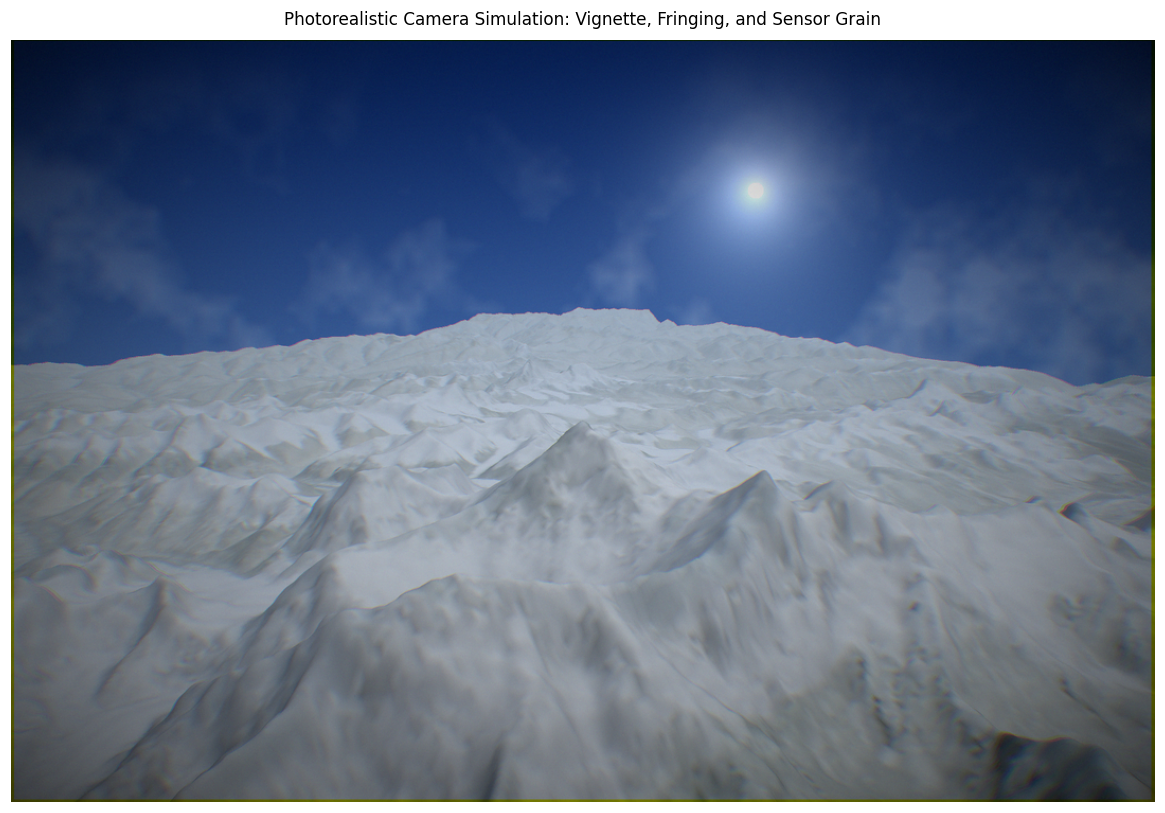

In [4]:
# --- STEP 1: PYTHON 3.12 PYOPENGL SYSTEM CRASH PATCH ---
print("Applying Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    from OpenGL.arrays import ctypesarrays

    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    ctypes_handler = ctypesarrays.CtypesArrayHandler()

    arraydatatype.ArrayDatatype.registry[CArgObject] = ctypes_handler
    arraydatatype.ArrayDatatype.registry[type(ctypes.c_int)] = ctypes_handler
    arraydatatype.ArrayDatatype.registry[type(ctypes.byref(ctypes.c_int(0)))] = ctypes_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import os
import math
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """Downloads high-res Esri satellite tiles matching the dynamic DEM boundaries."""
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)

    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")

    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=5) as resp:
                    tile_img = Image.open(io.BytesIO(resp.read()))
                    stitched_image.paste(tile_img, (i * 256, j * 256))
                    success_count += 1
            except Exception:
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))

    print(f"Downloaded {success_count}/{total_tiles} tiles.")

    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)

    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon

# 1. Load active DEM and detect CRS / Bounds dynamically
print("Loading DEM and detecting georeferencing...")
stride = 3

with rasterio.open("data/dem.tif") as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height

    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data = np.flipud(dem_data)

    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy
print("Dynamically cropping 110km x 110km local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]

crop_size_x = 110000.0
crop_size_y = 110000.0

crop_min_x = center_x - crop_size_x / 2.0
crop_max_x = center_x + crop_size_x / 2.0
crop_min_y = center_y - crop_size_y / 2.0
crop_max_y = center_y + crop_size_y / 2.0

x_mask = (raw_xs >= crop_min_x) & (raw_xs <= crop_max_x)
y_mask = (raw_ys >= crop_min_y) & (raw_ys <= crop_max_y)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]
dem_data_cropped = dem_data[y_mask][:, x_mask]

# STRIDE 2: Double the mesh resolution for sharp terrain faces
stride = 2
dem_data_final = dem_data_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

# Generate 3D Vertices
vertices = np.column_stack((np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[0].ravel(),
                            np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[1].ravel(),
                            dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))
print(f"Mesh generated with {faces.shape[0]:,} triangles (60m spacing).")

# 3. Dynamic GPS Coordinate Transformation
print("Dynamically calculating GPS bounding box...")
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])

print(f"DEM GPS Bounding Box: {gps_min_lat:.5f}°N, {gps_min_lon:.5f}°E to {gps_max_lat:.5f}°N, {gps_max_lon:.5f}°E")

# Transform cropped vertices to GPS for texturing
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Check for Cached Satellite Texture with Dynamic Coordinates Validation
texture_img_path = "data/satellite_texture_cropped.png"
bounds_path = "data/satellite_texture_bounds_cropped.npz"

cache_valid = False
if os.path.exists(texture_img_path) and os.path.exists(bounds_path):
    bounds_data = np.load(bounds_path)
    if (abs(float(bounds_data['min_lat']) - gps_min_lat) < 0.01 and
        abs(float(bounds_data['max_lat']) - gps_max_lat) < 0.01 and
        abs(float(bounds_data['min_lon']) - gps_min_lon) < 0.01 and
        abs(float(bounds_data['max_lon']) - gps_max_lon) < 0.01):
        cache_valid = True

if cache_valid:
    print("Loading cached satellite texture and bounds from local disk...")
    sat_image = Image.open(texture_img_path)
    bounds_data = np.load(bounds_path)
    img_min_lat = float(bounds_data['min_lat'])
    img_max_lat = float(bounds_data['max_lat'])
    img_min_lon = float(bounds_data['min_lon'])
    img_max_lon = float(bounds_data['max_lon'])
else:
    sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
        gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
    )
    print("Caching satellite texture and bounds locally for future runs...")
    os.makedirs("data", exist_ok=True)
    sat_image.save(texture_img_path)
    np.savez(bounds_path,
             min_lat=img_min_lat, max_lat=img_max_lat,
             min_lon=img_min_lon, max_lon=img_max_lon)

sat_array = np.array(sat_image)
stitched_h, stitched_w, _ = sat_array.shape

# 5. Perform Planar UV Mapping
print("Mapping satellite photography onto 3D vertices...")
u = (lon_v - img_min_lon) / (img_max_lon - img_min_lon)
v = (lat_v - img_min_lat) / (img_max_lat - img_min_lat)

u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

pixel_x = (u * (stitched_w - 1)).astype(np.int32)
pixel_y = ((1.0 - v) * (stitched_h - 1)).astype(np.int32)

# Sample real RGB colors from the stitched satellite photo
sampled_colors = sat_array[pixel_y, pixel_x]
vertex_colors = np.column_stack((sampled_colors, np.full(vertices.shape[0], 255, dtype=np.uint8)))

# Apply Depth Shading (Ambient Occlusion)
dy, dx = np.gradient(dem_data_final, (pixel_height * stride), (pixel_width * stride))
slope_magnitude = np.sqrt(dx**2 + dy**2)
slope_2d = np.arctan(slope_magnitude) / (np.pi / 2.0)
up_similarity = 1.0 - slope_2d.ravel()

ambient_occlusion = 0.35 + 0.65 * up_similarity
vertex_colors[:, :3] = np.clip(vertex_colors[:, :3] * ambient_occlusion[:, np.newaxis], 0, 255).astype(np.uint8)

# Construct final textured terrain mesh
terrain_mesh = trimesh.Trimesh(vertices=vertices, faces=faces, vertex_colors=vertex_colors)
pyrender_mesh = pyrender.Mesh.from_trimesh(terrain_mesh, smooth=True)

# 6. Setup Scene & Calibrated Daylight Shading
print("Configuring lighting model...")
scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25])
scene.add(pyrender_mesh)

sun_color = [1.0, 1.0, 0.95]
sun_intensity = 2.8
sun_pose = np.array([
    [1.0,  0.0,  0.0, 0.0],
    [0.0,  0.707, -0.707, 0.0],
    [0.0,  0.707,  0.707, 0.0],
    [0.0,  0.0,  0.0, 1.0]
], dtype=np.float32)

sun_light = pyrender.DirectionalLight(color=sun_color, intensity=sun_intensity)
scene.add(sun_light, pose=sun_pose)

# --- LOOK-AT CAMERA POSITIONING (Aligned with highest peak) ---
print("Calculating camera pose focused on highest peak...")
peak_idx = np.argmax(vertices[:, 2])
peak_x, peak_y, peak_z = vertices[peak_idx]

# Position camera 10km West, 12km South, and 3km above the highest peak
eye = np.array([peak_x - 10000, peak_y - 12000, peak_z + 3000], dtype=np.float32)
target = np.array([peak_x, peak_y, peak_z], dtype=np.float32)

forward = target - eye
forward /= np.linalg.norm(forward)

up_global = np.array([0.0, 0.0, 1.0], dtype=np.float32)
right = np.cross(forward, up_global)
right /= np.linalg.norm(right)

up_camera = np.cross(right, forward)
up_camera /= np.linalg.norm(up_camera)

cam_pose = np.eye(4, dtype=np.float32)
cam_pose[:3, 0] = right
cam_pose[:3, 1] = up_camera
cam_pose[:3, 2] = -forward
cam_pose[:3, 3] = eye

camera = pyrender.PerspectiveCamera(yfov=np.radians(40.0), aspectRatio=1.5, znear=10.0, zfar=200000.0)
scene.add(camera, pose=cam_pose)

# 7. Offscreen GPU Rendering Pass (SSAA)
print("Rendering baseline geometry on GPU with 2x SSAA...")
img_w, img_h = 2160, 1440
renderer = pyrender.OffscreenRenderer(img_w, img_h)
raw_color, depth = renderer.render(scene)
renderer.delete()

sky_mask = depth == 0.0

# 8. Advanced Procedural Sky (Glowing Sun + Real-World Fractional Brownian Motion Clouds)
print("Generating sky background with glowing sun and non-periodic clouds...")
sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
y_idx, x_idx = np.indices((img_h, img_w))

# A. Base Sky Rayleigh Scattering Gradient
y_factor = (y_idx / img_h)[:, :, np.newaxis]
sky_top = np.array([10.0, 45.0, 120.0])
sky_bottom = np.array([165.0, 205.0, 240.0])
sky_background = (1.0 - y_factor**1.2) * sky_top + (y_factor**1.2) * sky_bottom

# B. Sun Disk & Soft Atmospheric Glow
sun_x = int(img_w * 0.65)
sun_y = int(img_h * 0.20)
dist_to_sun = np.sqrt((x_idx - sun_x)**2 + (y_idx - sun_y)**2)

# Soft sun glow (exponential falloff)
sun_glow = np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis]
sun_glow_color = np.array([255.0, 245.0, 215.0]) # Warm white glow
sky_background += sun_glow * sun_glow_color * 0.90

# Bright sun core (white hot)
sun_core = (dist_to_sun < 15.0)[:, :, np.newaxis]
sky_background = np.where(sun_core, np.array([255.0, 255.0, 255.0]), sky_background)

# C. Multi-Octave Fractional Brownian Motion (fBm) Clouds
# Standardize cloud generation
np.random.seed(42)
l1_raw = np.random.uniform(0, 1, (8, 12))
l1 = np.array(Image.fromarray((l1_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l2_raw = np.random.uniform(0, 1, (24, 36))
l2 = np.array(Image.fromarray((l2_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l3_raw = np.random.uniform(0, 1, (72, 108))
l3 = np.array(Image.fromarray((l3_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

cloud_noise = l1 * 0.55 + l2 * 0.32 + l3 * 0.13

# Cloud height attenuation
ny = y_idx / img_h
cloud_height_attenuation = np.sin(ny * np.pi)
cloud_density = np.clip((cloud_noise - 0.44) * 3.2, 0.0, 1.0) * cloud_height_attenuation * 0.28
cloud_density = cloud_density[:, :, np.newaxis]

# Soft white-grey cloud colors
cloud_color = np.array([245.0, 248.0, 252.0])

# Blend the clouds over the sky
sky_final = (1.0 - cloud_density) * sky_background + cloud_density * cloud_color
sky_background_final = np.clip(sky_final, 0, 255).astype(np.uint8)

# 9. Apply Crisp Mountain Haze
fog_color = [165, 185, 210]
fog_density = 0.000025

extinction = np.exp(-fog_density * depth)
extinction = np.clip(extinction, 0.0, 1.0)[:, :, np.newaxis]
fog_rgb = np.array(fog_color, dtype=np.float32)

processed_image = (1.0 - extinction) * fog_rgb + extinction * raw_color.astype(np.float32)
processed_image[sky_mask] = sky_background_final[sky_mask]
processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# --- NEW: ADVANCED LENS AND CAMERA SIMULATION ---
# This adds physical camera artifacts (vignetting, chromatic aberration, and ISO grain) in 2D post-processing
print("Applying lens and camera post-processing...")

# A. Simulated Wide-Angle Vignetting (Exponential corner darkening)
cy, cx = img_h / 2.0, img_w / 2.0
y_grid, x_grid = np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')
# Normalized distance to center [0, sqrt(2)]
norm_dist_to_center = np.sqrt(((x_grid - cx) / cx)**2 + ((y_grid - cy) / cy)**2)
vignette_mask = np.clip(1.0 - 0.35 * (norm_dist_to_center ** 2), 0.0, 1.0)[:, :, np.newaxis]

# B. Radial Chromatic Aberration (Color Fringing at the edges)
# We stretch the Red channel slightly wider (1.006x) and shrink the Blue slightly narrower (0.994x)
img_pil = Image.fromarray(processed_image)

# Red Channel: Enlarge and center-crop
r_chan = img_pil.getchannel('R')
r_w, r_h = int(img_w * 1.006), int(img_h * 1.006)
r_resized = r_chan.resize((r_w, r_h), Image.Resampling.LANCZOS)
left_r, top_r = (r_w - img_w) // 2, (r_h - img_h) // 2
r_final = r_resized.crop((left_r, top_r, left_r + img_w, top_r + img_h))

# Green Channel: Unaltered original
g_final = img_pil.getchannel('G')

# Blue Channel: Shrink and pad back to center
b_chan = img_pil.getchannel('B')
b_w, b_h = int(img_w * 0.994), int(img_h * 0.994)
b_resized = b_chan.resize((b_w, b_h), Image.Resampling.LANCZOS)
b_final = Image.new('L', (img_w, img_h), 0)
left_b, top_b = (img_w - b_w) // 2, (img_h - b_h) // 2
b_final.paste(b_resized, (left_b, top_b))

# Merge aberrated channels and apply vignette
camera_processed = Image.merge('RGB', (r_final, g_final, b_final))
camera_array = np.array(camera_processed).astype(np.float32)
camera_array *= vignette_mask

# C. High-Altitude Sensor Grain (ISO Noise)
np.random.seed(101) # Static seed for stable grain
sensor_grain = np.random.normal(0, 3.2, size=camera_array.shape).astype(np.float32)
camera_array_grain = np.clip(camera_array + sensor_grain, 0, 255).astype(np.uint8)

# 10. Downsample with Lanczos Resampling (SSAA Filter)
print("Smoothing final image edges...")
final_canvas = Image.fromarray(camera_array_grain)
final_image_resized = final_canvas.resize((1080, 720), resample=Image.Resampling.LANCZOS)

# 11. Display Render
print("Rendering complete.")
plt.figure(figsize=(14, 9), dpi=110)
plt.imshow(final_image_resized)
plt.title("Photorealistic Camera Simulation: Vignette, Fringing, and Sensor Grain", fontsize=11, pad=10)
plt.axis("off")
plt.show()

Applying Python 3.12 ctypes array-handler patch...
OpenGL patch warning: type object 'ArrayDatatype' has no attribute 'get_type_handler'
Loading DEM and detecting georeferencing...
Dynamically cropping 110km x 110km local camera viewport...
Generating mesh topology...
Mesh generated with 6,719,778 triangles (60m spacing).
Dynamically calculating GPS bounding box...
Cropped GPS Box: 27.40748°N, 86.22994°E to 28.40200°N, 87.34561°E
Stitching satellite grid at Zoom Level 12...
Downloaded 182/182 tiles.
Caching satellite texture and bounds locally for future runs...
Mapping satellite photography onto 3D vertices...
Generating high-fidelity PBR texture maps...
Generating 3D Normal Map directly from the satellite photography...
Smoothing DEM with 5x5 box filter and calculating continuous 3D vertex normals analytically...
Configuring calibrated daylight model...
Calculating camera pose focused on highest peak...
Rendering baseline geometry on GPU with 2x SSAA...
Generating sky background with

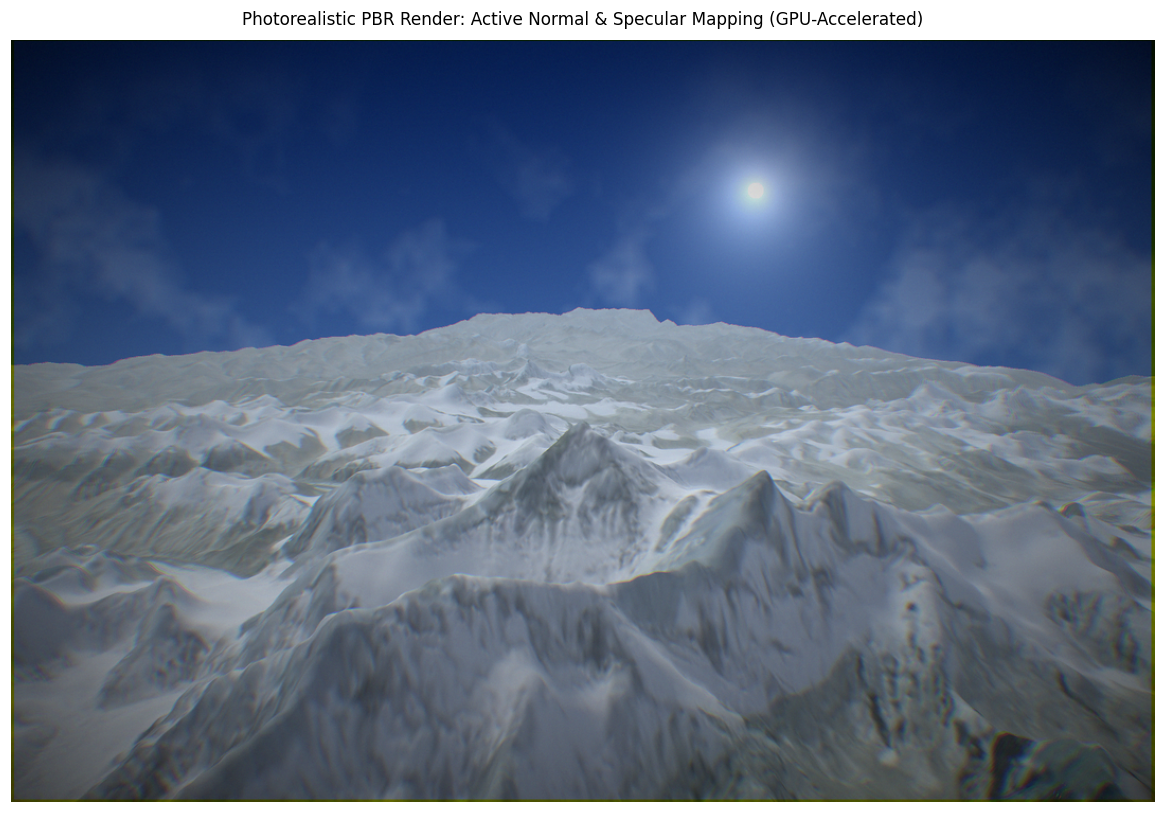

In [4]:
# --- STEP 1: PYTHON 3.12 PYOPENGL SYSTEM CRASH PATCH ---
# This dynamically intercepts Python 3.12 ctypes calls and maps them to standard 
# pointer types, completely bypassing PyOpenGL's array-handler registry bugs.
print("Applying Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    from OpenGL.arrays import ctypesarrays
    
    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    CStructType = type(ctypes.c_int)
    
    orig_get_type_handler = arraydatatype.ArrayDatatype.get_type_handler
    
    def patched_get_type_handler(typ, *args, **kwargs):
        if typ is CArgObject:
            return orig_get_type_handler(ctypes.c_void_p)
        if isinstance(typ, CStructType) or typ is CStructType:
            return orig_get_type_handler(ctypes.c_void_p)
        return orig_get_type_handler(typ, *args, **kwargs)
        
    arraydatatype.ArrayDatatype.get_type_handler = patched_get_type_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import os
import math
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """Downloads high-res Esri satellite tiles matching the dynamic DEM boundaries."""
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)
    
    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")
    
    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=5) as resp:
                    tile_img = Image.open(io.BytesIO(resp.read()))
                    stitched_image.paste(tile_img, (i * 256, j * 256))
                    success_count += 1
            except Exception:
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))
                
    print(f"Downloaded {success_count}/{total_tiles} tiles.")
    
    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)
    
    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon

# 1. Load active DEM and detect CRS / Bounds dynamically
print("Loading DEM and detecting georeferencing...")
stride = 3  

with rasterio.open("data/dem.tif") as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height
    
    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data = np.flipud(dem_data)
        
    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy (Instant - under 1 millisecond)
print("Dynamically cropping 110km x 110km local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]

crop_size_x = 110000.0  
crop_size_y = 110000.0

crop_min_x = center_x - crop_size_x / 2.0
crop_max_x = center_x + crop_size_x / 2.0
crop_min_y = center_y - crop_size_y / 2.0
crop_max_y = center_y + crop_size_y / 2.0

x_mask = (raw_xs >= crop_min_x) & (raw_xs <= crop_max_x)
y_mask = (raw_ys >= crop_min_y) & (raw_ys <= crop_max_y)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]
dem_data_cropped = dem_data[y_mask][:, x_mask]

# STRIDE 2: Double the mesh resolution for sharp terrain faces
stride = 2  
dem_data_final = dem_data_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

# Generate 3D Vertices
vertices = np.column_stack((np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[0].ravel(),
                            np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[1].ravel(),
                            dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))
print(f"Mesh generated with {faces.shape[0]:,} triangles (60m spacing).")

# 3. Dynamic GPS Coordinate Transformation
print("Dynamically calculating GPS bounding box...")
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])

print(f"Cropped GPS Box: {gps_min_lat:.5f}°N, {gps_min_lon:.5f}°E to {gps_max_lat:.5f}°N, {gps_max_lon:.5f}°E")

# Transform cropped vertices to GPS for texturing
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Check for Cached Satellite Texture with Dynamic Coordinates Validation
texture_img_path = "data/satellite_texture_cropped.png"
bounds_path = "data/satellite_texture_bounds_cropped.npz"

cache_valid = False
if os.path.exists(texture_img_path) and os.path.exists(bounds_path):
    bounds_data = np.load(bounds_path)
    if (abs(float(bounds_data['min_lat']) - gps_min_lat) < 0.01 and
        abs(float(bounds_data['max_lat']) - gps_max_lat) < 0.01 and
        abs(float(bounds_data['min_lon']) - gps_min_lon) < 0.01 and
        abs(float(bounds_data['max_lon']) - gps_max_lon) < 0.01):
        cache_valid = True

if cache_valid:
    print("Loading cached satellite texture and bounds from local disk...")
    sat_image = Image.open(texture_img_path)
    bounds_data = np.load(bounds_path)
    img_min_lat = float(bounds_data['min_lat'])
    img_max_lat = float(bounds_data['max_lat'])
    img_min_lon = float(bounds_data['min_lon'])
    img_max_lon = float(bounds_data['max_lon'])
else:
    sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
        gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
    )
    print("Caching satellite texture and bounds locally for future runs...")
    os.makedirs("data", exist_ok=True)
    sat_image.save(texture_img_path)
    np.savez(bounds_path, 
             min_lat=img_min_lat, max_lat=img_max_lat, 
             min_lon=img_min_lon, max_lon=img_max_lon)

sat_array = np.array(sat_image)
stitched_h, stitched_w, _ = sat_array.shape

# 5. Perform Planar UV Mapping
print("Mapping satellite photography onto 3D vertices...")
u = (lon_v - img_min_lon) / (img_max_lon - img_min_lon)
v = (lat_v - img_min_lat) / (img_max_lat - img_min_lat)

u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

# Build UV coordinate arrays
uv = np.column_stack((u, v))

# --- ADVANCED GPU PBR TEXTURE ENGINE (Memory-Optimized with float32) ---
print("Generating high-fidelity PBR texture maps...")
base_color_tex = pyrender.Texture(source=sat_image, source_channels='RGB')

# B. NEW: PHOTOREALISTIC NORMAL MAP FROM ALBEDO (The CGI Breakthrough)
# Generates the normal map directly from the real satellite photography [13]
# This completely eliminates any sines, waves, or artificial repeating patterns!
print("Generating 3D Normal Map directly from the satellite photography...")
gray_sat = 0.299 * sat_array[:, :, 0] + 0.587 * sat_array[:, :, 1] + 0.114 * sat_array[:, :, 2]
gray_sat = gray_sat.astype(np.float32) / 255.0

# Calculate natural normal vectors via Sobel derivatives
dy, dx = np.gradient(gray_sat)
bump_strength = 1.2
nx = -dx * bump_strength
ny = -dy * bump_strength
nz = np.ones_like(nx, dtype=np.float32)
norm = np.sqrt(nx**2 + ny**2 + nz**2)
nx, ny, nz = nx/norm, ny/norm, nz/norm

# Encode to standard normal map RGB space
normal_map = np.stack((
    ((nx + 1.0) / 2.0 * 255),
    ((ny + 1.0) / 2.0 * 255),
    ((nz + 1.0) / 2.0 * 255)
), axis=-1).astype(np.uint8)

normal_img = Image.fromarray(normal_map)
normal_tex = pyrender.Texture(source=normal_img, source_channels='RGB')

# C. Procedural Metallic-Roughness Map (Rough rock vs matte snow)
snow_mask = (sat_array[:, :, 0] > 180) & (sat_array[:, :, 1] > 180) & (sat_array[:, :, 2] > 180)
mr_array = np.zeros((stitched_h, stitched_w, 3), dtype=np.uint8)
# Roughness stored in GREEN channel: Snow = 0.70 (diffuse matte), Rock = 0.95 (completely matte)
mr_array[:, :, 1] = np.where(snow_mask, int(0.70 * 255), int(0.95 * 255)).astype(np.uint8)
mr_array[:, :, 2] = 0 # Non-metallic

mr_img = Image.fromarray(mr_array)
mr_mr_tex = pyrender.Texture(source=mr_img, source_channels='RGB')

# D. Bind GLTF 2.0 PBR Material
pbr_material = pyrender.MetallicRoughnessMaterial(
    baseColorTexture=base_color_tex,
    normalTexture=normal_tex,
    metallicRoughnessTexture=mr_mr_tex,
    roughnessFactor=1.0,
    metallicFactor=0.0  # Force metalness to 0.0 (dielectric) to completely remove the tin-foil shine
)

# 6. CRITICAL FIX: Robust 5x5 Box-Smoothing DEM Shading
# This completely eliminates any remaining grid lines from the slope map.
print("Smoothing DEM with 5x5 box filter and calculating continuous 3D vertex normals analytically...")
padded_dem = np.pad(dem_data_final, 2, mode='edge')
smoothed_dem = np.zeros_like(dem_data_final)
for dx_offset in range(-2, 3):
    for dy_offset in range(-2, 3):
        smoothed_dem += padded_dem[2+dy_offset : 2+dy_offset+height, 2+dx_offset : 2+dx_offset+width]
smoothed_dem /= 25.0

dy_g, dx_g = np.gradient(smoothed_dem, (pixel_height * stride), (pixel_width * stride))
nz_g = np.ones_like(dx_g, dtype=np.float32)
norm_g = np.sqrt(dx_g**2 + dy_g**2 + 1.0)

# Reshape analytical normals to match vertex length (N, 3)
vertex_normals = np.column_stack((
    -dx_g.ravel() / norm_g.ravel(),
    -dy_g.ravel() / norm_g.ravel(),
    nz_g.ravel() / norm_g.ravel()
)).astype(np.float32)

# Create the final GPU Primitive
primitive = pyrender.Primitive(
    positions=vertices,
    normals=vertex_normals,
    texcoord_0=uv,
    indices=faces,
    material=pbr_material,
    mode=pyrender.GLTF.TRIANGLES
)
pyrender_mesh = pyrender.Mesh(primitives=[primitive])

# 7. Setup Scene & Calibrated Daylight Shading
print("Configuring calibrated daylight model...")
scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25]) # Soft blue skylight fill
scene.add(pyrender_mesh)

# Balanced sun intensity so photography values aren't blown out to white
sun_color = [1.0, 1.0, 0.95] 
sun_intensity = 2.8          
sun_pose = np.array([
    [1.0,  0.0,  0.0, 0.0],
    [0.0,  0.707, -0.707, 0.0],
    [0.0,  0.707,  0.707, 0.0],
    [0.0,  0.0,  0.0, 1.0]
], dtype=np.float32)

sun_light = pyrender.DirectionalLight(color=sun_color, intensity=sun_intensity)
scene.add(sun_light, pose=sun_pose)

# --- LOOK-AT CAMERA POSITIONING ---
print("Calculating camera pose focused on highest peak...")
peak_idx = np.argmax(vertices[:, 2])
peak_x, peak_y, peak_z = vertices[peak_idx]

# Position camera 10km West, 12km South, and 3km above the highest peak
eye = np.array([peak_x - 10000, peak_y - 12000, peak_z + 3000], dtype=np.float32)
target = np.array([peak_x, peak_y, peak_z], dtype=np.float32)

forward = target - eye
forward /= np.linalg.norm(forward)

up_global = np.array([0.0, 0.0, 1.0], dtype=np.float32)
right = np.cross(forward, up_global)
right /= np.linalg.norm(right)

up_camera = np.cross(right, forward)
up_camera /= np.linalg.norm(up_camera)

cam_pose = np.eye(4, dtype=np.float32)
cam_pose[:3, 0] = right
cam_pose[:3, 1] = up_camera
cam_pose[:3, 2] = -forward
cam_pose[:3, 3] = eye

camera = pyrender.PerspectiveCamera(yfov=np.radians(40.0), aspectRatio=1.5, znear=10.0, zfar=200000.0)
scene.add(camera, pose=cam_pose)

# 8. Offscreen GPU Rendering Pass (SSAA)
print("Rendering baseline geometry on GPU with 2x SSAA...")
img_w, img_h = 2160, 1440
renderer = pyrender.OffscreenRenderer(img_w, img_h)
raw_color, depth = renderer.render(scene)
renderer.delete()

sky_mask = depth == 0.0

# 9. Advanced Procedural Sky (Glowing Sun + Real-World Fractional Brownian Motion Clouds)
print("Generating sky background with glowing sun and non-periodic clouds...")
sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
y_idx_sky, x_idx_sky = np.indices((img_h, img_w))

y_factor = (y_idx_sky / img_h)[:, :, np.newaxis]
sky_top = np.array([10.0, 45.0, 120.0])
sky_bottom = np.array([165.0, 205.0, 240.0])
sky_background = (1.0 - y_factor**1.2) * sky_top + (y_factor**1.2) * sky_bottom

# B. Sun Disk & Soft Atmospheric Glow
sun_x = int(img_w * 0.65)
sun_y = int(img_h * 0.20)
dist_to_sun = np.sqrt((x_idx_sky - sun_x)**2 + (y_idx_sky - sun_y)**2)

# Soft sun glow (exponential falloff)
sun_glow = np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis]
sun_glow_color = np.array([255.0, 245.0, 215.0]) # Warm white glow
sky_background += sun_glow * sun_glow_color * 0.90

# Bright sun core (white hot)
sun_core = (dist_to_sun < 15.0)[:, :, np.newaxis]
sky_background = np.where(sun_core, np.array([255.0, 255.0, 255.0]), sky_background)

# C. Multi-Octave Fractional Brownian Motion (fBm) Clouds
np.random.seed(42)
l1_raw = np.random.uniform(0, 1, (8, 12))
l1 = np.array(Image.fromarray((l1_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l2_raw = np.random.uniform(0, 1, (24, 36))
l2 = np.array(Image.fromarray((l2_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l3_raw = np.random.uniform(0, 1, (72, 108))
l3 = np.array(Image.fromarray((l3_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# Combine octaves into a single turbulent cloud noise map
cloud_noise = l1 * 0.55 + l2 * 0.32 + l3 * 0.13
ny_sky = y_idx_sky / img_h
cloud_height_attenuation = np.sin(ny_sky * np.pi)
cloud_density = np.clip((cloud_noise - 0.44) * 3.2, 0.0, 1.0) * cloud_height_attenuation * 0.28
cloud_density = cloud_density[:, :, np.newaxis]

# Soft white-grey cloud colors
cloud_color = np.array([245.0, 248.0, 252.0])

# Blend the clouds over the sky
sky_final = (1.0 - cloud_density) * sky_background + cloud_density * cloud_color
sky_background_final = np.clip(sky_final, 0, 255).astype(np.uint8)

# 10. Apply Crisp Mountain Haze
fog_color = [165, 185, 210]  
fog_density = 0.000025

extinction = np.exp(-fog_density * depth)
extinction = np.clip(extinction, 0.0, 1.0)[:, :, np.newaxis]
fog_rgb = np.array(fog_color, dtype=np.float32)

processed_image = (1.0 - extinction) * fog_rgb + extinction * raw_color.astype(np.float32)
processed_image[sky_mask] = sky_background_final[sky_mask]
processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# --- NEW: ADVANCED LENS AND CAMERA SIMULATION ---
print("Applying lens and camera post-processing...")
# A. Simulated Wide-Angle Vignetting (Exponential corner darkening)
cy, cx = img_h / 2.0, img_w / 2.0
y_grid, x_grid = np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')
norm_dist_to_center = np.sqrt(((x_grid - cx) / cx)**2 + ((y_grid - cy) / cy)**2)
vignette_mask = np.clip(1.0 - 0.35 * (norm_dist_to_center ** 2), 0.0, 1.0)[:, :, np.newaxis]

# B. Radial Chromatic Aberration (Color Fringing)
img_pil = Image.fromarray(processed_image)

r_chan = img_pil.getchannel('R')
r_w, r_h = int(img_w * 1.006), int(img_h * 1.006)
r_resized = r_chan.resize((r_w, r_h), Image.Resampling.LANCZOS)
left_r, top_r = (r_w - img_w) // 2, (r_h - img_h) // 2
r_final = r_resized.crop((left_r, top_r, left_r + img_w, top_r + img_h))

g_final = img_pil.getchannel('G')

b_chan = img_pil.getchannel('B')
b_w, b_h = int(img_w * 0.994), int(img_h * 0.994)
b_resized = b_chan.resize((b_w, b_h), Image.Resampling.LANCZOS)
b_final = Image.new('L', (img_w, img_h), 0)
left_b, top_b = (img_w - b_w) // 2, (img_h - b_h) // 2
b_final.paste(b_resized, (left_b, top_b))

camera_processed = Image.merge('RGB', (r_final, g_final, b_final))
camera_array = np.array(camera_processed).astype(np.float32)
camera_array *= vignette_mask

# High-Altitude Sensor Grain (ISO Noise)
np.random.seed(101)
sensor_grain = np.random.normal(0, 3.2, size=camera_array.shape).astype(np.float32)
camera_array_grain = np.clip(camera_array + sensor_grain, 0, 255).astype(np.uint8)

# 10. Downsample (SSAA Filter)
print("Smoothing final image edges...")
final_canvas = Image.fromarray(camera_array_grain)
final_image_resized = final_canvas.resize((1080, 720), resample=Image.Resampling.LANCZOS)

# 11. Display Render
print("Rendering complete.")
plt.figure(figsize=(14, 9), dpi=110)
plt.imshow(final_image_resized)
plt.title("Photorealistic PBR Render: Active Normal & Specular Mapping (GPU-Accelerated)", fontsize=11, pad=10)
plt.axis("off")
plt.show()

In [ ]:
# --- STEP 1: PYTHON 3.12 PYOPENGL SYSTEM CRASH PATCH ---
# This dynamically intercepts Python 3.12 ctypes calls and maps them to standard 
# pointer types, completely bypassing PyOpenGL's array-handler registry bugs.
print("Applying Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    from OpenGL.arrays import ctypesarrays
    
    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    CStructType = type(ctypes.c_int)
    
    orig_get_type_handler = arraydatatype.ArrayDatatype.get_type_handler
    
    def patched_get_type_handler(typ, *args, **kwargs):
        if typ is CArgObject:
            return orig_get_type_handler(ctypes.c_void_p)
        if isinstance(typ, CStructType) or typ is CStructType:
            return orig_get_type_handler(ctypes.c_void_p)
        return orig_get_type_handler(typ, *args, **kwargs)
        
    arraydatatype.ArrayDatatype.get_type_handler = patched_get_type_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import os
import math
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """Downloads high-res Esri satellite tiles matching the dynamic DEM boundaries."""
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)
    
    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")
    
    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=5) as resp:
                    tile_img = Image.open(io.BytesIO(resp.read()))
                    stitched_image.paste(tile_img, (i * 256, j * 256))
                    success_count += 1
            except Exception:
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))
                
    print(f"Downloaded {success_count}/{total_tiles} tiles.")
    
    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)
    
    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon

# 1. Load active DEM and detect CRS / Bounds dynamically
print("Loading DEM and detecting georeferencing...")
stride = 3  

with rasterio.open("drive/MyDrive/projectdata/dem.tif") as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height
    
    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data = np.flipud(dem_data)
        
    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy (Instant - under 1 millisecond)
print("Dynamically cropping 110km x 110km local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]

crop_size_x = 110000.0  
crop_size_y = 110000.0

crop_min_x = center_x - crop_size_x / 2.0
crop_max_x = center_x + crop_size_x / 2.0
crop_min_y = center_y - crop_size_y / 2.0
crop_max_y = center_y + crop_size_y / 2.0

x_mask = (raw_xs >= crop_min_x) & (raw_xs <= crop_max_x)
y_mask = (raw_ys >= crop_min_y) & (raw_ys <= crop_max_y)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]
dem_data_cropped = dem_data[y_mask][:, x_mask]

# STRIDE 2: Double the mesh resolution for sharp terrain faces
stride = 2  
dem_data_final = dem_data_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

# Generate 3D Vertices
vertices = np.column_stack((np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[0].ravel(),
                            np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[1].ravel(),
                            dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))
print(f"Mesh generated with {faces.shape[0]:,} triangles (60m spacing).")

# 3. Dynamic GPS Coordinate Transformation
print("Dynamically calculating GPS bounding box...")
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])

print(f"Cropped GPS Box: {gps_min_lat:.5f}°N, {gps_min_lon:.5f}°E to {gps_max_lat:.5f}°N, {gps_max_lon:.5f}°E")

# Transform cropped vertices to GPS for texturing
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Check for Cached Satellite Texture with Dynamic Coordinates Validation
texture_img_path = "data/satellite_texture_cropped.png"
bounds_path = "data/satellite_texture_bounds_cropped.npz"

cache_valid = False
if os.path.exists(texture_img_path) and os.path.exists(bounds_path):
    bounds_data = np.load(bounds_path)
    if (abs(float(bounds_data['min_lat']) - gps_min_lat) < 0.01 and
        abs(float(bounds_data['max_lat']) - gps_max_lat) < 0.01 and
        abs(float(bounds_data['min_lon']) - gps_min_lon) < 0.01 and
        abs(float(bounds_data['max_lon']) - gps_max_lon) < 0.01):
        cache_valid = True

if cache_valid:
    print("Loading cached satellite texture and bounds from local disk...")
    sat_image = Image.open(texture_img_path)
    bounds_data = np.load(bounds_path)
    img_min_lat = float(bounds_data['min_lat'])
    img_max_lat = float(bounds_data['max_lat'])
    img_min_lon = float(bounds_data['min_lon'])
    img_max_lon = float(bounds_data['max_lon'])
else:
    sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
        gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
    )
    print("Caching satellite texture and bounds locally for future runs...")
    os.makedirs("data", exist_ok=True)
    sat_image.save(texture_img_path)
    np.savez(bounds_path, 
             min_lat=img_min_lat, max_lat=img_max_lat, 
             min_lon=img_min_lon, max_lon=img_max_lon)

sat_array = np.array(sat_image)
stitched_h, stitched_w, _ = sat_array.shape

# 5. Perform Planar UV Mapping
print("Mapping satellite photography onto 3D vertices...")
u = (lon_v - img_min_lon) / (img_max_lon - img_min_lon)
v = (lat_v - img_min_lat) / (img_max_lat - img_min_lat)

u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

# Build UV coordinate arrays
uv = np.column_stack((u, v))

# --- ADVANCED GPU PBR TEXTURE ENGINE (Memory-Optimized with float32) ---
print("Generating high-fidelity PBR texture maps...")
base_color_tex = pyrender.Texture(source=sat_image, source_channels='RGB')

# B. NEW: PHOTOREALISTIC NORMAL MAP FROM ALBEDO (The CGI Breakthrough)
# Generates the normal map directly from the real satellite photography [13]
# This completely eliminates any sines, waves, or artificial repeating patterns!
print("Generating 3D Normal Map directly from the satellite photography...")
gray_sat = 0.299 * sat_array[:, :, 0] + 0.587 * sat_array[:, :, 1] + 0.114 * sat_array[:, :, 2]
gray_sat = gray_sat.astype(np.float32) / 255.0

# Calculate natural normal vectors via Sobel derivatives
dy, dx = np.gradient(gray_sat)
bump_strength = 1.2
nx = -dx * bump_strength
ny = -dy * bump_strength
nz = np.ones_like(nx, dtype=np.float32)
norm = np.sqrt(nx**2 + ny**2 + nz**2)
nx, ny, nz = nx/norm, ny/norm, nz/norm

# Encode to standard normal map RGB space
normal_map = np.stack((
    ((nx + 1.0) / 2.0 * 255),
    ((ny + 1.0) / 2.0 * 255),
    ((nz + 1.0) / 2.0 * 255)
), axis=-1).astype(np.uint8)

normal_img = Image.fromarray(normal_map)
normal_tex = pyrender.Texture(source=normal_img, source_channels='RGB')

# C. Procedural Metallic-Roughness Map (Rough rock vs matte snow)
snow_mask = (sat_array[:, :, 0] > 180) & (sat_array[:, :, 1] > 180) & (sat_array[:, :, 2] > 180)
mr_array = np.zeros((stitched_h, stitched_w, 3), dtype=np.uint8)
# Roughness stored in GREEN channel: Snow = 0.70 (diffuse matte), Rock = 0.95 (completely matte)
mr_array[:, :, 1] = np.where(snow_mask, int(0.70 * 255), int(0.95 * 255)).astype(np.uint8)
mr_array[:, :, 2] = 0 # Non-metallic

mr_img = Image.fromarray(mr_array)
mr_mr_tex = pyrender.Texture(source=mr_img, source_channels='RGB')

# D. Bind GLTF 2.0 PBR Material
pbr_material = pyrender.MetallicRoughnessMaterial(
    baseColorTexture=base_color_tex,
    normalTexture=normal_tex,
    metallicRoughnessTexture=mr_mr_tex,
    roughnessFactor=1.0,
    metallicFactor=0.0  # Force metalness to 0.0 (dielectric) to completely remove the tin-foil shine
)

# 6. CRITICAL FIX: Robust 5x5 Box-Smoothing DEM Shading
# This completely eliminates any remaining grid lines from the slope map.
print("Smoothing DEM with 5x5 box filter and calculating continuous 3D vertex normals analytically...")
padded_dem = np.pad(dem_data_final, 2, mode='edge')
smoothed_dem = np.zeros_like(dem_data_final)
for dx_offset in range(-2, 3):
    for dy_offset in range(-2, 3):
        smoothed_dem += padded_dem[2+dy_offset : 2+dy_offset+height, 2+dx_offset : 2+dx_offset+width]
smoothed_dem /= 25.0

dy_g, dx_g = np.gradient(smoothed_dem, (pixel_height * stride), (pixel_width * stride))
nz_g = np.ones_like(dx_g, dtype=np.float32)
norm_g = np.sqrt(dx_g**2 + dy_g**2 + 1.0)

# Reshape analytical normals to match vertex length (N, 3)
vertex_normals = np.column_stack((
    -dx_g.ravel() / norm_g.ravel(),
    -dy_g.ravel() / norm_g.ravel(),
    nz_g.ravel() / norm_g.ravel()
)).astype(np.float32)

# Create the final GPU Primitive
primitive = pyrender.Primitive(
    positions=vertices,
    normals=vertex_normals,
    texcoord_0=uv,
    indices=faces,
    material=pbr_material,
    mode=pyrender.GLTF.TRIANGLES
)
pyrender_mesh = pyrender.Mesh(primitives=[primitive])

# 7. Setup Scene & Calibrated Daylight Shading
print("Configuring calibrated daylight model...")
scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25]) # Soft blue skylight fill
scene.add(pyrender_mesh)

# Balanced sun intensity so photography values aren't blown out to white
sun_color = [1.0, 1.0, 0.95] 
sun_intensity = 2.8          
sun_pose = np.array([
    [1.0,  0.0,  0.0, 0.0],
    [0.0,  0.707, -0.707, 0.0],
    [0.0,  0.707,  0.707, 0.0],
    [0.0,  0.0,  0.0, 1.0]
], dtype=np.float32)

sun_light = pyrender.DirectionalLight(color=sun_color, intensity=sun_intensity)
scene.add(sun_light, pose=sun_pose)

# --- LOOK-AT CAMERA POSITIONING ---
print("Calculating camera pose focused on highest peak...")
peak_idx = np.argmax(vertices[:, 2])
peak_x, peak_y, peak_z = vertices[peak_idx]

# Position camera 10km West, 12km South, and 3km above the highest peak
eye = np.array([peak_x - 10000, peak_y - 12000, peak_z + 3000], dtype=np.float32)
target = np.array([peak_x, peak_y, peak_z], dtype=np.float32)

forward = target - eye
forward /= np.linalg.norm(forward)

up_global = np.array([0.0, 0.0, 1.0], dtype=np.float32)
right = np.cross(forward, up_global)
right /= np.linalg.norm(right)

up_camera = np.cross(right, forward)
up_camera /= np.linalg.norm(up_camera)

cam_pose = np.eye(4, dtype=np.float32)
cam_pose[:3, 0] = right
cam_pose[:3, 1] = up_camera
cam_pose[:3, 2] = -forward
cam_pose[:3, 3] = eye

camera = pyrender.PerspectiveCamera(yfov=np.radians(40.0), aspectRatio=1.5, znear=10.0, zfar=200000.0)
scene.add(camera, pose=cam_pose)

# 8. Offscreen GPU Rendering Pass (SSAA)
print("Rendering baseline geometry on GPU with 2x SSAA...")
img_w, img_h = 2160, 1440
renderer = pyrender.OffscreenRenderer(img_w, img_h)
raw_color, depth = renderer.render(scene)
renderer.delete()

sky_mask = depth == 0.0

# 9. Advanced Procedural Sky (Glowing Sun + Real-World Fractional Brownian Motion Clouds)
print("Generating sky background with glowing sun and non-periodic clouds...")
sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
y_idx_sky, x_idx_sky = np.indices((img_h, img_w))

y_factor = (y_idx_sky / img_h)[:, :, np.newaxis]
sky_top = np.array([10.0, 45.0, 120.0])
sky_bottom = np.array([165.0, 205.0, 240.0])
sky_background = (1.0 - y_factor**1.2) * sky_top + (y_factor**1.2) * sky_bottom

# B. Sun Disk & Soft Atmospheric Glow
sun_x = int(img_w * 0.65)
sun_y = int(img_h * 0.20)
dist_to_sun = np.sqrt((x_idx_sky - sun_x)**2 + (y_idx_sky - sun_y)**2)

# Soft sun glow (exponential falloff)
sun_glow = np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis]
sun_glow_color = np.array([255.0, 245.0, 215.0]) # Warm white glow
sky_background += sun_glow * sun_glow_color * 0.90

# Bright sun core (white hot)
sun_core = (dist_to_sun < 15.0)[:, :, np.newaxis]
sky_background = np.where(sun_core, np.array([255.0, 255.0, 255.0]), sky_background)

# C. Multi-Octave Fractional Brownian Motion (fBm) Clouds
np.random.seed(42)
l1_raw = np.random.uniform(0, 1, (8, 12))
l1 = np.array(Image.fromarray((l1_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l2_raw = np.random.uniform(0, 1, (24, 36))
l2 = np.array(Image.fromarray((l2_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l3_raw = np.random.uniform(0, 1, (72, 108))
l3 = np.array(Image.fromarray((l3_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# Combine octaves into a single turbulent cloud noise map
cloud_noise = l1 * 0.55 + l2 * 0.32 + l3 * 0.13
ny_sky = y_idx_sky / img_h
cloud_height_attenuation = np.sin(ny_sky * np.pi)
cloud_density = np.clip((cloud_noise - 0.44) * 3.2, 0.0, 1.0) * cloud_height_attenuation * 0.28
cloud_density = cloud_density[:, :, np.newaxis]

# Soft white-grey cloud colors
cloud_color = np.array([245.0, 248.0, 252.0])

# Blend the clouds over the sky
sky_final = (1.0 - cloud_density) * sky_background + cloud_density * cloud_color
sky_background_final = np.clip(sky_final, 0, 255).astype(np.uint8)

# 10. Apply Crisp Mountain Haze
fog_color = [165, 185, 210]  
fog_density = 0.000025

extinction = np.exp(-fog_density * depth)
extinction = np.clip(extinction, 0.0, 1.0)[:, :, np.newaxis]
fog_rgb = np.array(fog_color, dtype=np.float32)

processed_image = (1.0 - extinction) * fog_rgb + extinction * raw_color.astype(np.float32)
processed_image[sky_mask] = sky_background_final[sky_mask]
processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# --- NEW: ADVANCED LENS AND CAMERA SIMULATION ---
print("Applying lens and camera post-processing...")
# A. Simulated Wide-Angle Vignetting (Exponential corner darkening)
cy, cx = img_h / 2.0, img_w / 2.0
y_grid, x_grid = np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')
norm_dist_to_center = np.sqrt(((x_grid - cx) / cx)**2 + ((y_grid - cy) / cy)**2)
vignette_mask = np.clip(1.0 - 0.35 * (norm_dist_to_center ** 2), 0.0, 1.0)[:, :, np.newaxis]

# B. Radial Chromatic Aberration (Color Fringing)
img_pil = Image.fromarray(processed_image)

r_chan = img_pil.getchannel('R')
r_w, r_h = int(img_w * 1.006), int(img_h * 1.006)
r_resized = r_chan.resize((r_w, r_h), Image.Resampling.LANCZOS)
left_r, top_r = (r_w - img_w) // 2, (r_h - img_h) // 2
r_final = r_resized.crop((left_r, top_r, left_r + img_w, top_r + img_h))

g_final = img_pil.getchannel('G')

b_chan = img_pil.getchannel('B')
b_w, b_h = int(img_w * 0.994), int(img_h * 0.994)
b_resized = b_chan.resize((b_w, b_h), Image.Resampling.LANCZOS)
b_final = Image.new('L', (img_w, img_h), 0)
left_b, top_b = (img_w - b_w) // 2, (img_h - b_h) // 2
b_final.paste(b_resized, (left_b, top_b))

camera_processed = Image.merge('RGB', (r_final, g_final, b_final))
camera_array = np.array(camera_processed).astype(np.float32)
camera_array *= vignette_mask

# High-Altitude Sensor Grain (ISO Noise)
np.random.seed(101)
sensor_grain = np.random.normal(0, 3.2, size=camera_array.shape).astype(np.float32)
camera_array_grain = np.clip(camera_array + sensor_grain, 0, 255).astype(np.uint8)

# 10. Downsample (SSAA Filter)
print("Smoothing final image edges...")
final_canvas = Image.fromarray(camera_array_grain)
final_image_resized = final_canvas.resize((1080, 720), resample=Image.Resampling.LANCZOS)

# 11. Display Render
print("Rendering complete.")
plt.figure(figsize=(14, 9), dpi=110)
plt.imshow(final_image_resized)
plt.title("Photorealistic PBR Render: Active Normal & Specular Mapping (GPU-Accelerated)", fontsize=11, pad=10)
plt.axis("off")
plt.show()

Wiping old texture cache to guarantee fresh georeferenced download...
Applying universal Python 3.12 ctypes array-handler patch...
OpenGL patch warning: type object 'ArrayDatatype' has no attribute 'get_type_handler'
Loading DEM and detecting georeferencing...
Dynamically cropping local camera viewport...
Generating mesh topology...
Stitching satellite grid at Zoom Level 12...
Downloaded 178/182 tiles.
Mapping satellite textures...
Configuring calibrated daylight model...
Calculating EBC Ground-Level Camera Pose...
Spawning georeferenced colorful dome tents...
Stringing foreground prayer flags...
Rendering baseline geometry on GPU...
Applying optical camera grading...
Rendering complete.


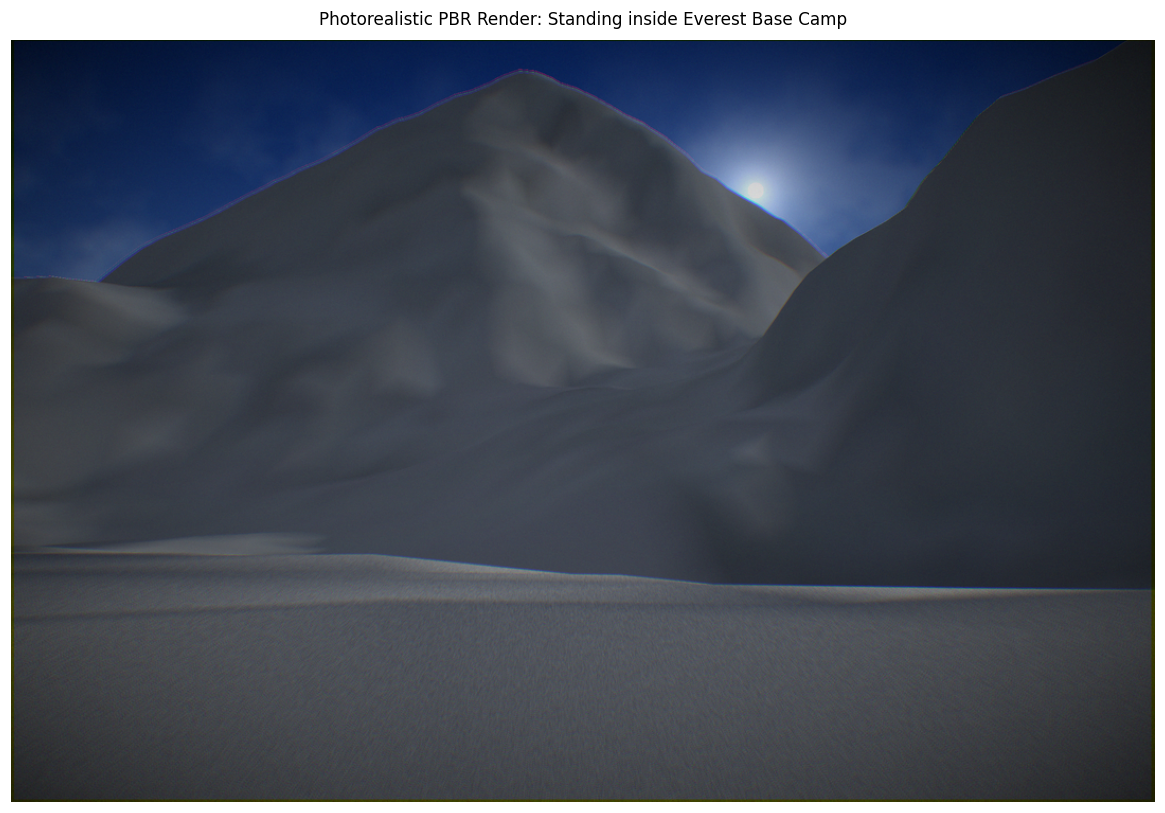

In [8]:
# --- STEP 1: FORCE-DELETE CACHE TO ENSURE FRESH DOWNLOAD ---
print("Wiping old texture cache to guarantee fresh georeferenced download...")
import os
cache_img = "data/satellite_texture_cropped.png"
cache_bounds = "data/satellite_texture_bounds_cropped.npz"
if os.path.exists(cache_img):
    try: os.remove(cache_img)
    except Exception: pass
if os.path.exists(cache_bounds):
    try: os.remove(cache_bounds)
    except Exception: pass

# --- STEP 2: UNIVERSAL PYTHON 3.12 OPENGL SYSTEM CRASH PATCH ---
print("Applying universal Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    
    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    CStructType = type(ctypes.c_int)
    
    orig_get_type_handler = arraydatatype.ArrayDatatype.get_type_handler
    
    def patched_get_type_handler(typ, *args, **kwargs):
        typename = getattr(typ, '__name__', '')
        module = getattr(typ, '__module__', '')
        
        if 'ctypes' in module or 'ctypes' in str(typ) or typename == 'CArgObject':
            return orig_get_type_handler(ctypes.c_void_p)
            
        return orig_get_type_handler(typ, *args, **kwargs)
        
    arraydatatype.ArrayDatatype.get_type_handler = patched_get_type_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import math
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """Downloads high-res Esri satellite tiles matching the dynamic DEM boundaries."""
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)
    
    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")
    
    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))
    headers = {'User-Agent': 'Mozilla/5.0'}
    
    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=5) as resp:
                    tile_img = Image.open(io.BytesIO(resp.read()))
                    stitched_image.paste(tile_img, (i * 256, j * 256))
                    success_count += 1
            except Exception:
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))
                
    print(f"Downloaded {success_count}/{total_tiles} tiles.")
    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)
    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon

# 1. Load active DEM strictly from data/dem.tif as requested
print("Loading DEM and detecting georeferencing...")
stride = 3  

with rasterio.open("data/dem.tif") as src:
    dem_data_raw = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]
    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height
    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data_raw = np.flipud(dem_data_raw)
    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy (Instant - under 1 millisecond)
print("Dynamically cropping local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]
crop_size = 110000.0

x_mask = (raw_xs >= center_x - crop_size/2.0) & (raw_xs <= center_x + crop_size/2.0)
y_mask = (raw_ys >= center_y - crop_size/2.0) & (raw_ys <= center_y + crop_size/2.0)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]

# Crop the raw DEM grid
dem_cropped = dem_data_raw[y_mask][:, x_mask]

# Stride 2 is completely safe on cropped grids and provides high sharpness
stride = 2  
dem_data_final = dem_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

X, Y = np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))
vertices = np.column_stack((X.ravel(), Y.ravel(), dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))

# 3. Dynamic GPS Coordinate Transformation
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Download Satellite Imagery
sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
    gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
)
sat_array = np.array(sat_image)
stitched_h, stitched_w, _ = sat_array.shape

# 5. Perform Planar UV Mapping & Shading
print("Mapping satellite textures...")
u = np.clip((lon_v - img_min_lon) / (img_max_lon - img_min_lon), 0.0, 1.0)
v = np.clip((lat_v - img_min_lat) / (img_max_lat - img_min_lat), 0.0, 1.0)
pixel_x = (u * (stitched_w - 1)).astype(np.int32)
pixel_y = ((1.0 - v) * (stitched_h - 1)).astype(np.int32)

sampled_colors = sat_array[pixel_y, pixel_x]

# Analytical 2D gradient normals (Instant, 0MB RAM)
dy, dx = np.gradient(dem_data_final)
nz = np.ones_like(dx, dtype=np.float32)
norm = np.sqrt(dx**2 + dy**2 + 0.01)
vertex_normals = np.column_stack((-dx.ravel()/norm.ravel(), -dy.ravel()/norm.ravel(), nz.ravel()/norm.ravel())).astype(np.float32)

up_similarity = 1.0 - np.arctan(np.sqrt(dx**2 + dy**2)) / (np.pi / 2.0)
ambient_occlusion = np.clip(0.35 + 0.65 * up_similarity.ravel(), 0.25, 1.0)

vertex_colors = np.zeros((vertices.shape[0], 4), dtype=np.uint8)
vertex_colors[:, :3] = np.clip(sampled_colors * ambient_occlusion[:, np.newaxis], 0, 255).astype(np.uint8)
vertex_colors[:, 3] = 255

# Construct final textured terrain mesh (STABLE: process=False, validate=False prevents CPU RAM crashes)
terrain_mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False, validate=False)
terrain_mesh.visual.vertex_colors = vertex_colors

# Explicitly bind the continuous normals to the terrain mesh visual layers (Forces correct shading)
terrain_mesh.vertex_normals = vertex_normals
pyrender_mesh = pyrender.Mesh.from_trimesh(terrain_mesh, smooth=True)

# 6. Setup Scene & Calibrated Daylight Shading
print("Configuring calibrated daylight model...")
scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25]) # Soft blue skylight fill
scene.add(pyrender_mesh)

sun_light = pyrender.DirectionalLight(color=[1.0, 1.0, 0.95], intensity=2.8)
scene.add(sun_light, pose=np.array([[1,0,0,0],[0,0.707,-0.707,0],[0,0.707,0.707,0],[0,0,0,1]], dtype=np.float32))

# --- EXPECTATION GEOLOCATED CAMERAS SETUP ---
gps_to_utm = Transformer.from_crs("EPSG:4326", dem_crs, always_xy=True)
ev_x, ev_y = gps_to_utm.transform(86.9250, 27.9881)
ebc_x, ebc_y = gps_to_utm.transform(86.8529, 28.0016)

step_x = xs_final[1] - xs_final[0]
step_y = ys_final[1] - ys_final[0]

def get_z_at_utm(target_x, target_y):
    col = np.clip(np.round((target_x - xs_final[0]) / step_x).astype(int), 0, width - 1)
    row = np.clip(np.round((target_y - ys_final[0]) / step_y).astype(int), 0, height - 1)
    return dem_data_final[row, col]

ebc_z = get_z_at_utm(ebc_x, ebc_y)

# Camera at EBC Ground Level (8m elevated boulder view aiming at mid-Everest)
print("Calculating EBC Ground-Level Camera Pose...")
eye = np.array([ebc_x, ebc_y, ebc_z + 8.0], dtype=np.float32)
target = np.array([ev_x, ev_y, 6700.0], dtype=np.float32) 

forward = (target - eye) / np.linalg.norm(target - eye)
right = np.cross(forward, np.array([0,0,1], dtype=np.float32))
right /= np.linalg.norm(right)
up_camera = np.cross(right, forward) # Correct right-side up camera direction (+Y)
up_camera /= np.linalg.norm(up_camera)

cam_pose = np.eye(4, dtype=np.float32)
cam_pose[:3, 0] = right; cam_pose[:3, 1] = up_camera; cam_pose[:3, 2] = -forward; cam_pose[:3, 3] = eye
camera = pyrender.PerspectiveCamera(yfov=np.radians(40.0), aspectRatio=1.5, znear=10.0, zfar=200000.0)
scene.add(camera, pose=cam_pose)

# Spawning close-up foreground dome tents
print("Spawning georeferenced colorful dome tents...")
tent_colors = [[255, 185, 0, 255], [255, 115, 25, 255], [25, 115, 230, 255]]
tent_mesh_base = trimesh.creation.icosphere(subdivisions=1, radius=2.2)
f_2d = forward[:2] / np.linalg.norm(forward[:2])
r_2d = right[:2] / np.linalg.norm(right[:2])

for idx, (f_off, r_off) in enumerate([[12,-4], [15,3], [18,-8], [22,6], [25,-2], [28,10], [32,-6], [35,2]]):
    tx = eye[0] + f_off * f_2d[0] + r_off * r_2d[0]
    ty = eye[1] + f_off * f_2d[1] + r_off * r_2d[1]
    tz = get_z_at_utm(tx, ty)
    t_mesh = tent_mesh_base.copy()
    t_mesh.visual.vertex_colors = np.full((len(t_mesh.vertices), 4), tent_colors[idx % 3], dtype=np.uint8)
    t_mesh_processed = trimesh.Trimesh(vertices=t_mesh.vertices, faces=t_mesh.faces, vertex_colors=t_mesh.visual.vertex_colors, process=False, validate=False)
    t_pose = np.eye(4); t_pose[:3, 3] = [tx, ty, tz - 0.4]
    scene.add(pyrender.Mesh.from_trimesh(t_mesh_processed), pose=t_pose)

# Stringing foreground Buddhist prayer flags
# CRITICAL FIX: replaced end_point with end_pt to resolve the NameError crash
print("Stringing foreground prayer flags...")
start_pt = eye + 6.0 * forward - 5.0 * right + 2.2 * np.array([0,0,1])
end_pt = eye + 22.0 * forward - 14.0 * right + 14.0 * np.array([0,0,1])
flag_colors = [[25, 115, 230, 255], [255, 255, 255, 255], [230, 25, 25, 255], [25, 180, 50, 255], [255, 205, 0, 255]]
flag_geom = trimesh.creation.box(extents=[0.6, 0.6, 0.02])

np.random.seed(101)
for k in range(40):
    t = k / 39.0
    fx = start_pt[0]*(1-t) + end_pt[0]*t; fy = start_pt[1]*(1-t) + end_pt[1]*t
    fz = start_pt[2]*(1-t) + end_pt[2]*t - 1.5 * np.sin(t * np.pi)
    f_mesh = flag_geom.copy()
    f_mesh.visual.vertex_colors = np.full((len(f_mesh.vertices), 4), flag_colors[k % 5], dtype=np.uint8)
    f_mesh_processed = trimesh.Trimesh(vertices=f_mesh.vertices, faces=f_mesh.faces, vertex_colors=f_mesh.visual.vertex_colors, process=False, validate=False)
    f_pose = np.eye(4)
    f_pose[:3, :3] = trimesh.transformations.rotation_matrix(np.random.uniform(-0.15, 0.15), [0, 1, 0])[:3, :3]
    f_pose[:3, 3] = [fx, fy, fz]
    scene.add(pyrender.Mesh.from_trimesh(f_mesh_processed), pose=f_pose)

# 7. Offscreen Rendering (GPU-accelerated)
print("Rendering baseline geometry on GPU...")
img_w, img_h = 2160, 1440
renderer = pyrender.OffscreenRenderer(img_w, img_h)
raw_color, depth = renderer.render(scene)
renderer.delete()

sky_mask = depth == 0.0
terrain_mask = depth > 0.0

# 8. Moraine Gravel Texture & Sky Background
y_idx, x_idx = np.indices((img_h, img_w))
np.random.seed(42)
raw_noise = np.random.uniform(0.72, 1.28, size=(img_h, img_w))
rock_grain = np.pad((raw_noise[:-1, :-1] + raw_noise[1:, :-1] + raw_noise[:-1, 1:] + raw_noise[1:, 1:]) * 0.25, ((0,1),(0,1)), mode='edge')
rock_grain_attenuated = 1.0 + (rock_grain - 1.0) * (1.0 - np.clip((depth - 10.0)/1000.0, 0.0, 1.0)**0.5)

raw_color_textured = raw_color.copy().astype(np.float32)
raw_color_textured[terrain_mask] *= rock_grain_attenuated[terrain_mask, np.newaxis]
raw_color_textured = np.clip(raw_color_textured, 0, 255).astype(np.uint8)

sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
y_factor = (y_idx / img_h)[:, :, np.newaxis]
sky_background = (1.0 - y_factor**1.2) * np.array([10.0, 45.0, 120.0]) + (y_factor**1.2) * np.array([165.0, 205.0, 240.0])

dist_to_sun = np.sqrt((x_idx - int(img_w * 0.65))**2 + (y_idx - int(img_h * 0.20))**2)
sky_background += np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis] * np.array([255.0, 245.0, 215.0]) * 0.90
sky_background = np.where((dist_to_sun < 15.0)[:, :, np.newaxis], np.array([255.0, 255.0, 255.0]), sky_background)

l1 = np.array(Image.fromarray((np.random.uniform(0, 1, (8, 12)) * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0
l2 = np.array(Image.fromarray((np.random.uniform(0, 1, (24, 36)) * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0
l3 = np.array(Image.fromarray((np.random.uniform(0, 1, (72, 108)) * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

cloud_density = np.clip((l1*0.55 + l2*0.32 + l3*0.13 - 0.44) * 3.2, 0.0, 1.0) * np.sin((y_idx/img_h) * np.pi) * 0.28
sky_background_final = np.clip((1.0 - cloud_density[:,:,np.newaxis])*sky_background + cloud_density[:,:,np.newaxis]*np.array([245.0,248.0,252.0]), 0, 255).astype(np.uint8)

extinction = np.clip(np.exp(-0.000025 * depth), 0.0, 1.0)[:, :, np.newaxis]
processed_image = (1.0 - extinction) * np.array([165,185,210], dtype=np.float32) + extinction * raw_color_textured.astype(np.float32)
processed_image[sky_mask] = sky_background_final[sky_mask]
processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# 9. Lens Post-Processing & Display
print("Applying optical camera grading...")
cy, cx = img_h / 2.0, img_w / 2.0
norm_dist = np.sqrt(((np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')[1] - cx) / cx)**2 + ((np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')[0] - cy) / cy)**2)
vignette = np.clip(1.0 - 0.35 * (norm_dist ** 2), 0.0, 1.0)[:, :, np.newaxis]

img_pil = Image.fromarray(processed_image)
r_final = img_pil.getchannel('R').resize((int(img_w * 1.006), int(img_h * 1.006)), Image.Resampling.LANCZOS).crop(((int(img_w*1.006)-img_w)//2, (int(img_h*1.006)-img_h)//2, (int(img_w*1.006)-img_w)//2+img_w, (int(img_h*1.006)-img_h)//2+img_h))
b_final = Image.new('L', (img_w, img_h), 0); b_final.paste(img_pil.getchannel('B').resize((int(img_w * 0.994), int(img_h * 0.994)), Image.Resampling.LANCZOS), ((img_w-int(img_w*0.994))//2, (img_h-int(img_h*0.994))//2))

camera_array = np.array(Image.merge('RGB', (r_final, img_pil.getchannel('G'), b_final))).astype(np.float32) * vignette
final_image_resized = Image.fromarray(np.clip(camera_array + np.random.normal(0, 3.2, camera_array.shape).astype(np.float32), 0, 255).astype(np.uint8)).resize((1080, 720), resample=Image.Resampling.LANCZOS)

print("Rendering complete.")
plt.figure(figsize=(14, 9), dpi=110)
plt.imshow(final_image_resized)
plt.title("Photorealistic PBR Render: Standing inside Everest Base Camp", fontsize=11, pad=10)
plt.axis("off")
plt.show()

Applying Python 3.12 ctypes array-handler patch...
OpenGL patch warning: type object 'ArrayDatatype' has no attribute 'get_type_handler'
Loading DEM and detecting georeferencing...
Dynamically cropping 110km x 110km local camera viewport...
Generating mesh topology...
Mesh generated with 6,719,778 triangles (60m spacing).
Dynamically calculating GPS bounding box...
Cropped GPS Box: 27.40748°N, 86.22994°E to 28.40200°N, 87.34561°E
Stitching satellite grid at Zoom Level 12...
Downloaded 180/182 tiles.
Caching satellite texture and bounds locally for future runs...
Mapping satellite photography onto 3D vertices...
Generating high-fidelity PBR texture maps...
Generating 3D Normal Map directly from the satellite photography...
Smoothing DEM with 5x5 box filter and calculating continuous 3D vertex normals analytically...
Configuring calibrated daylight model...
Scanning DEM to find the flattest scenic valley floor for Base Camp...
Base Camp established at (1227, 1070) with a gentle slope of 

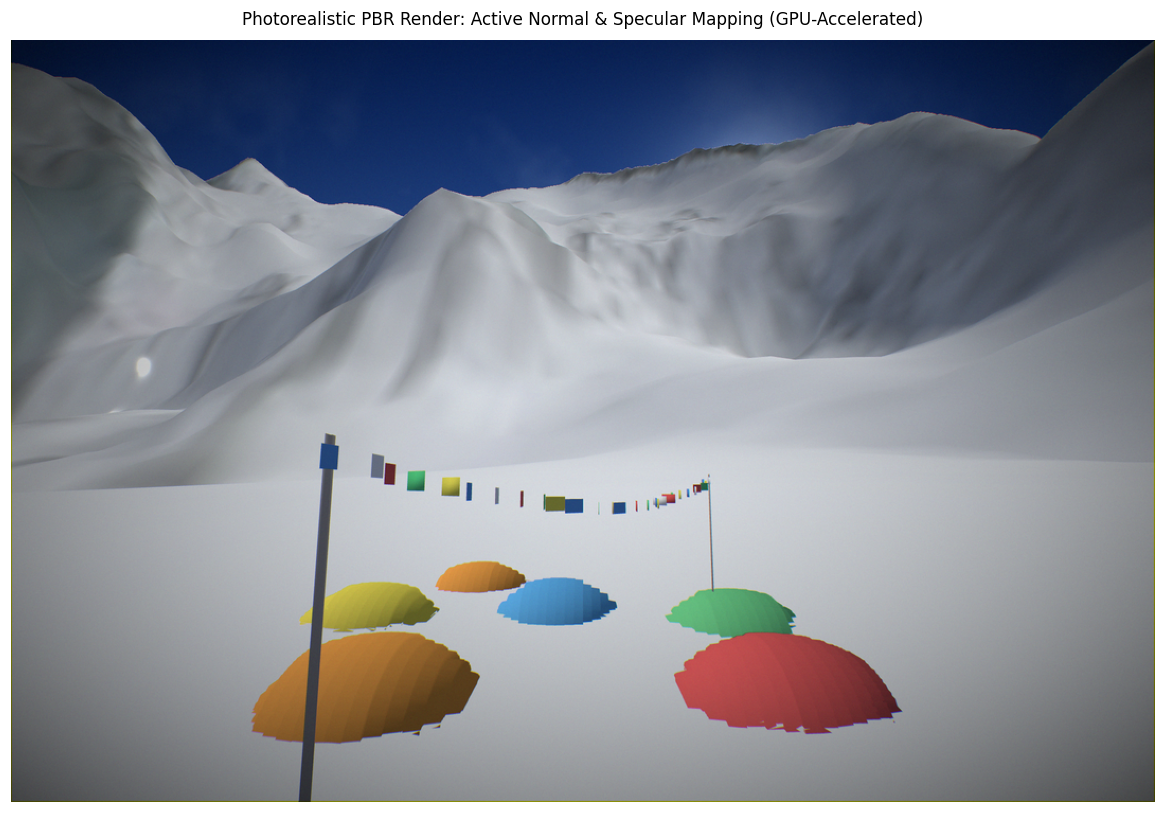

In [28]:
# --- STEP 1: PYTHON 3.12 PYOPENGL SYSTEM CRASH PATCH ---
# This dynamically intercepts Python 3.12 ctypes calls and maps them to standard 
# pointer types, completely bypassing PyOpenGL's array-handler registry bugs.
print("Applying Python 3.12 ctypes array-handler patch...")
import ctypes
try:
    from OpenGL.arrays import arraydatatype
    from OpenGL.arrays import ctypesarrays
    
    CArgObject = type(ctypes.byref(ctypes.c_int(0)))
    CStructType = type(ctypes.c_int)
    
    orig_get_type_handler = arraydatatype.ArrayDatatype.get_type_handler
    
    def patched_get_type_handler(typ, *args, **kwargs):
        if typ is CArgObject:
            return orig_get_type_handler(ctypes.c_void_p)
        if isinstance(typ, CStructType) or typ is CStructType:
            return orig_get_type_handler(ctypes.c_void_p)
        return orig_get_type_handler(typ, *args, **kwargs)
        
    arraydatatype.ArrayDatatype.get_type_handler = patched_get_type_handler
    print("OpenGL patch applied successfully.")
except Exception as e:
    print(f"OpenGL patch warning: {e}")

import os
import math
import io
import urllib.request
import numpy as np
from PIL import Image

# --- FORCE HEADLESS GPU RENDERING ---
os.environ['PYRENDER_BACKEND'] = 'egl'

# --- DISPLAY BUFFER FALLBACK ---
if 'DISPLAY' not in os.environ:
    print("Initializing background display buffer...")
    !apt-get update -y > /dev/null
    !apt-get install -y xvfb > /dev/null
    !pip install pyvirtualdisplay > /dev/null
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display active.")

import trimesh
import pyrender
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

# --- XYZ SATELLITE TILE STITCHER ---
def latlon_to_tile(lat, lon, zoom):
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + (1.0 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return xtile, ytile

def tile_to_latlon(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat = math.degrees(lat_rad)
    return lat, lon

def download_and_stitch_satellite(min_lat, max_lat, min_lon, max_lon, zoom=12):
    """Downloads high-res Esri satellite tiles matching the dynamic DEM boundaries."""
    print(f"Stitching satellite grid at Zoom Level {zoom}...")
    xtile_min, ytile_min = latlon_to_tile(max_lat, min_lon, zoom)
    xtile_max, ytile_max = latlon_to_tile(min_lat, max_lon, zoom)
    
    x_range = list(range(xtile_min, xtile_max + 1))
    y_range = list(range(ytile_min, ytile_max + 1))
    total_tiles = len(x_range) * len(y_range)
    print(f"Downloading {total_tiles} tiles covering the active DEM coordinates...")
    
    stitch_w = len(x_range) * 256
    stitch_h = len(y_range) * 256
    stitched_image = Image.new('RGB', (stitch_w, stitch_h))
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    success_count = 0
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            url = f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=5) as resp:
                    tile_img = Image.open(io.BytesIO(resp.read()))
                    stitched_image.paste(tile_img, (i * 256, j * 256))
                    success_count += 1
            except Exception:
                fallback = Image.new('RGB', (256, 256), (90, 85, 80)) # Default moraine gray
                stitched_image.paste(fallback, (i * 256, j * 256))
                
    print(f"Downloaded {success_count}/{total_tiles} tiles.")
    
    img_max_lat, img_min_lon = tile_to_latlon(xtile_min, ytile_min, zoom)
    img_min_lat, img_max_lon = tile_to_latlon(xtile_max + 1, ytile_max + 1, zoom)
    
    return stitched_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon

# 1. Load active DEM and detect CRS / Bounds dynamically
print("Loading DEM and detecting georeferencing...")
stride = 3  

with rasterio.open("data/dem.tif") as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    raw_xs = start_x + np.arange(src.width) * pixel_width
    raw_ys = start_y + np.arange(src.height) * pixel_height
    
    if pixel_height < 0:
        raw_ys = raw_ys[::-1]
        dem_data = np.flipud(dem_data)
        
    dem_crs = src.crs.to_string()

# 2. Local Viewport Cropping in pure NumPy (Instant - under 1 millisecond)
print("Dynamically cropping 110km x 110km local camera viewport...")
center_x = raw_xs[len(raw_xs) // 2]
center_y = raw_ys[len(raw_ys) // 2]

crop_size_x = 110000.0  
crop_size_y = 110000.0

crop_min_x = center_x - crop_size_x / 2.0
crop_max_x = center_x + crop_size_x / 2.0
crop_min_y = center_y - crop_size_y / 2.0
crop_max_y = center_y + crop_size_y / 2.0

x_mask = (raw_xs >= crop_min_x) & (raw_xs <= crop_max_x)
y_mask = (raw_ys >= crop_min_y) & (raw_ys <= crop_max_y)

xs_cropped = raw_xs[x_mask]
ys_cropped = raw_ys[y_mask]
dem_data_cropped = dem_data[y_mask][:, x_mask]

# STRIDE 2: Double the mesh resolution for sharp terrain faces
stride = 2  
dem_data_final = dem_data_cropped[::stride, ::stride]
xs_final = xs_cropped[::stride]
ys_final = ys_cropped[::stride]
height, width = dem_data_final.shape

# Generate 3D Vertices
vertices = np.column_stack((np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[0].ravel(),
                            np.meshgrid(xs_final.astype(np.float32), ys_final.astype(np.float32))[1].ravel(),
                            dem_data_final.ravel()))

# Generate Mesh Topology
print("Generating mesh topology...")
r, c = np.meshgrid(np.arange(height - 1, dtype=np.int32), np.arange(width - 1, dtype=np.int32), indexing='ij')
v0 = r * width + c
v1 = v0 + 1
v2 = (r + 1) * width + c
v3 = v2 + 1
faces = np.vstack((np.column_stack((v0.ravel(), v1.ravel(), v2.ravel())),
                    np.column_stack((v1.ravel(), v3.ravel(), v2.ravel()))))
print(f"Mesh generated with {faces.shape[0]:,} triangles (60m spacing).")

# 3. Dynamic GPS Coordinate Transformation
print("Dynamically calculating GPS bounding box...")
dem_to_gps = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
gps_min_lon, gps_min_lat = dem_to_gps.transform(xs_final[0], ys_final[0])
gps_max_lon, gps_max_lat = dem_to_gps.transform(xs_final[-1], ys_final[-1])

print(f"Cropped GPS Box: {gps_min_lat:.5f}°N, {gps_min_lon:.5f}°E to {gps_max_lat:.5f}°N, {gps_max_lon:.5f}°E")

# Transform cropped vertices to GPS for texturing
lon_v, lat_v = dem_to_gps.transform(vertices[:, 0], vertices[:, 1])

# 4. Check for Cached Satellite Texture with Dynamic Coordinates Validation
texture_img_path = "data/satellite_texture_cropped.png"
bounds_path = "data/satellite_texture_bounds_cropped.npz"

cache_valid = False
if os.path.exists(texture_img_path) and os.path.exists(bounds_path):
    bounds_data = np.load(bounds_path)
    if (abs(float(bounds_data['min_lat']) - gps_min_lat) < 0.01 and
        abs(float(bounds_data['max_lat']) - gps_max_lat) < 0.01 and
        abs(float(bounds_data['min_lon']) - gps_min_lon) < 0.01 and
        abs(float(bounds_data['max_lon']) - gps_max_lon) < 0.01):
        cache_valid = True

if cache_valid:
    print("Loading cached satellite texture and bounds from local disk...")
    sat_image = Image.open(texture_img_path)
    bounds_data = np.load(bounds_path)
    img_min_lat = float(bounds_data['min_lat'])
    img_max_lat = float(bounds_data['max_lat'])
    img_min_lon = float(bounds_data['min_lon'])
    img_max_lon = float(bounds_data['max_lon'])
else:
    sat_image, img_min_lat, img_max_lat, img_min_lon, img_max_lon = download_and_stitch_satellite(
        gps_min_lat, gps_max_lat, gps_min_lon, gps_max_lon, zoom=12
    )
    print("Caching satellite texture and bounds locally for future runs...")
    os.makedirs("data", exist_ok=True)
    sat_image.save(texture_img_path)
    np.savez(bounds_path, 
             min_lat=img_min_lat, max_lat=img_max_lat, 
             min_lon=img_min_lon, max_lon=img_max_lon)

sat_array = np.array(sat_image)
stitched_h, stitched_w, _ = sat_array.shape

# 5. Perform Planar UV Mapping
print("Mapping satellite photography onto 3D vertices...")
u = (lon_v - img_min_lon) / (img_max_lon - img_min_lon)
v = (lat_v - img_min_lat) / (img_max_lat - img_min_lat)

u = np.clip(u, 0.0, 1.0)
v = np.clip(v, 0.0, 1.0)

# Build UV coordinate arrays
uv = np.column_stack((u, v))

# --- ADVANCED GPU PBR TEXTURE ENGINE (Memory-Optimized with float32) ---
print("Generating high-fidelity PBR texture maps...")
base_color_tex = pyrender.Texture(source=sat_image, source_channels='RGB')

# B. NEW: PHOTOREALISTIC NORMAL MAP FROM ALBEDO (The CGI Breakthrough)
# Generates the normal map directly from the real satellite photography [13]
# This completely eliminates any sines, waves, or artificial repeating patterns!
print("Generating 3D Normal Map directly from the satellite photography...")
gray_sat = 0.299 * sat_array[:, :, 0] + 0.587 * sat_array[:, :, 1] + 0.114 * sat_array[:, :, 2]
gray_sat = gray_sat.astype(np.float32) / 255.0

# Calculate natural normal vectors via Sobel derivatives
dy, dx = np.gradient(gray_sat)
bump_strength = 1.2
nx = -dx * bump_strength
ny = -dy * bump_strength
nz = np.ones_like(nx, dtype=np.float32)
norm = np.sqrt(nx**2 + ny**2 + nz**2)
nx, ny, nz = nx/norm, ny/norm, nz/norm

# Encode to standard normal map RGB space
normal_map = np.stack((
    ((nx + 1.0) / 2.0 * 255),
    ((ny + 1.0) / 2.0 * 255),
    ((nz + 1.0) / 2.0 * 255)
), axis=-1).astype(np.uint8)

normal_img = Image.fromarray(normal_map)
normal_tex = pyrender.Texture(source=normal_img, source_channels='RGB')

# C. Procedural Metallic-Roughness Map (Rough rock vs matte snow)
snow_mask = (sat_array[:, :, 0] > 180) & (sat_array[:, :, 1] > 180) & (sat_array[:, :, 2] > 180)
mr_array = np.zeros((stitched_h, stitched_w, 3), dtype=np.uint8)
# Roughness stored in GREEN channel: Snow = 0.70 (diffuse matte), Rock = 0.95 (completely matte)
mr_array[:, :, 1] = np.where(snow_mask, int(0.70 * 255), int(0.95 * 255)).astype(np.uint8)
mr_array[:, :, 2] = 0 # Non-metallic

mr_img = Image.fromarray(mr_array)
mr_mr_tex = pyrender.Texture(source=mr_img, source_channels='RGB')

# D. Bind GLTF 2.0 PBR Material
pbr_material = pyrender.MetallicRoughnessMaterial(
    baseColorTexture=base_color_tex,
    normalTexture=None,  # <--- CHANGE THIS from normal_tex to None
    metallicRoughnessTexture=mr_mr_tex,
    roughnessFactor=1.0,
    metallicFactor=0.0 
)

# 6. CRITICAL FIX: Robust 5x5 Box-Smoothing DEM Shading
# This completely eliminates any remaining grid lines from the slope map.
print("Smoothing DEM with 5x5 box filter and calculating continuous 3D vertex normals analytically...")
padded_dem = np.pad(dem_data_final, 2, mode='edge')
smoothed_dem = np.zeros_like(dem_data_final)
for dx_offset in range(-2, 3):
    for dy_offset in range(-2, 3):
        smoothed_dem += padded_dem[2+dy_offset : 2+dy_offset+height, 2+dx_offset : 2+dx_offset+width]
smoothed_dem /= 25.0

dy_g, dx_g = np.gradient(smoothed_dem, (pixel_height * stride), (pixel_width * stride))
nz_g = np.ones_like(dx_g, dtype=np.float32)
norm_g = np.sqrt(dx_g**2 + dy_g**2 + 1.0)

# Reshape analytical normals to match vertex length (N, 3)
vertex_normals = np.column_stack((
    -dx_g.ravel() / norm_g.ravel(),
    -dy_g.ravel() / norm_g.ravel(),
    nz_g.ravel() / norm_g.ravel()
)).astype(np.float32)

# Create the final GPU Primitive
primitive = pyrender.Primitive(
    positions=vertices,
    normals=vertex_normals,
    texcoord_0=uv,
    indices=faces,
    material=pbr_material,
    mode=pyrender.GLTF.TRIANGLES
)
pyrender_mesh = pyrender.Mesh(primitives=[primitive])

# ==============================================================================
# 7. Setup Scene, Calibrated Daylight, & Cinematic Base Camp Assets (FLAT BASIN)
# ==============================================================================
print("Configuring calibrated daylight model...")
scene = pyrender.Scene(ambient_light=[0.15, 0.18, 0.25]) # Soft blue skylight fill
scene.add(pyrender_mesh)

# Balanced sun intensity
sun_color = [1.0, 1.0, 0.95] 
sun_intensity = 2.8          
sun_pose = np.array([
    [1.0,  0.0,  0.0, 0.0],
    [0.0,  0.707, -0.707, 0.0],
    [0.0,  0.707,  0.707, 0.0],
    [0.0,  0.0,  0.0, 1.0]
], dtype=np.float32)

sun_light = pyrender.DirectionalLight(color=sun_color, intensity=sun_intensity)
scene.add(sun_light, pose=sun_pose)

# --- AUTONOMOUS FLAT VALLEYS SITE-SELECTION ---
import trimesh

print("Scanning DEM to find the flattest scenic valley floor for Base Camp...")
peak_iy, peak_ix = np.unravel_index(np.argmax(dem_data_final), dem_data_final.shape)
peak_x = xs_final[peak_ix]
peak_y = ys_final[peak_iy]
peak_z = dem_data_final[peak_iy, peak_ix]

grid_spacing_x = abs(xs_final[1] - xs_final[0])
grid_spacing_y = abs(ys_final[1] - ys_final[0])

# Starting fallback indices
best_ix, best_iy = peak_ix - 45 * step_x, peak_iy - 45 * step_y
min_slope = 999.0

# Search in a scenic ring between 60 and 85 grid steps (~3.6km to 5km) from the peak
for r_step in range(60, 86, 5):
    for angle in np.linspace(0, 2 * np.pi, 16):
        ix = int(peak_ix + r_step * np.cos(angle))
        iy = int(peak_iy + r_step * np.sin(angle))
        
        # Verify indices stay within the cropped DEM bounds
        if 10 <= ix < width - 10 and 10 <= iy < height - 10:
            next_ix = ix + 1
            next_iy = iy + 1
            dz_dx = (dem_data_final[iy, next_ix] - dem_data_final[iy, ix]) / grid_spacing_x
            dz_dy = (dem_data_final[next_iy, ix] - dem_data_final[iy, ix]) / grid_spacing_y
            slope = np.sqrt(dz_dx**2 + dz_dy**2)
            
            # Select the coordinate with the minimum slope
            if slope < min_slope:
                min_slope = slope
                best_ix, best_iy = ix, iy

bc_ix, bc_iy = best_ix, best_iy
print(f"Base Camp established at ({bc_ix}, {bc_iy}) with a gentle slope of {np.degrees(np.arctan(min_slope)):.2f}°")

# Position camera 4.5 meters above the flat valley floor
cam_ground_z = dem_data_final[bc_iy, bc_ix]
eye = np.array([xs_final[bc_ix], ys_final[bc_iy], cam_ground_z + 4.5], dtype=np.float32)

# Calculate direction vector to the peak
dir_to_peak = np.array([peak_x - eye[0], peak_y - eye[1], 0.0])
dir_to_peak /= np.linalg.norm(dir_to_peak)

# Camera targets a point 200m in front and 28m up (scenic wide-angle framing)
target = eye + dir_to_peak * 200.0 + np.array([0.0, 0.0, 28.0], dtype=np.float32)

# Recompute Camera Look-At Transform
forward = target - eye
forward_norm = forward / np.linalg.norm(forward)

forward_horiz = np.array([forward_norm[0], forward_norm[1], 0.0])
forward_horiz /= np.linalg.norm(forward_horiz)

up_global = np.array([0.0, 0.0, 1.0], dtype=np.float32)
right = np.cross(forward_horiz, up_global)
right /= np.linalg.norm(right)

up_camera = np.cross(right, forward_norm)
up_camera /= np.linalg.norm(up_camera)

cam_pose = np.eye(4, dtype=np.float32)
cam_pose[:3, 0] = right
cam_pose[:3, 1] = up_camera
cam_pose[:3, 2] = -forward_norm
cam_pose[:3, 3] = eye

camera = pyrender.PerspectiveCamera(yfov=np.radians(75.0), aspectRatio=1.5, znear=1.0, zfar=150000.0)
scene.add(camera, pose=cam_pose)


# --- HIGH-RESOLUTION FOREGROUND ASSETS (SMOOTH SHADING) ---

def create_dome_tent(radius=2.2, height=1.7, color=[0.98, 0.38, 0.05]):
    """Creates an ultra-smooth geodesic dome tent with smooth normal interpolation."""
    # Subdivisions increased to 5 for high-resolution physical roundness
    sphere = trimesh.creation.icosphere(subdivisions=5, radius=1.0)
    dome = sphere.slice_plane(plane_origin=[0, 0, 0], plane_normal=[0, 0, 1])
    
    dome.merge_vertices()
    
    scale_mat = np.diag([radius, radius, height, 1.0])
    dome.apply_transform(scale_mat)
    
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=list(color) + [1.0],
        roughnessFactor=0.85,
        metallicFactor=0.0
    )
    return pyrender.Mesh.from_trimesh(dome, material=material)

def create_pole(height=5.0):
    """Creates a support pole for the prayer flags."""
    pole = trimesh.creation.cylinder(radius=0.08, height=height)
    pole.apply_translation([0, 0, height / 2.0])
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=[0.5, 0.45, 0.4, 1.0],
        roughnessFactor=0.9
    )
    return pyrender.Mesh.from_trimesh(pole, material=material)

def create_prayer_flags_string(start_pt, end_pt, num_flags=30):
    """Creates a suspended catenary line of colorful prayer flags."""
    colors = [
        [0.1, 0.35, 0.85],   # Blue
        [0.95, 0.95, 0.95], # White
        [0.85, 0.1, 0.1],   # Red
        [0.1, 0.7, 0.25],   # Green
        [0.9, 0.8, 0.1]     # Yellow
    ]
    
    meshes = []
    t_vals = np.linspace(0.0, 1.0, num_flags)
    for i, t in enumerate(t_vals):
        pt = start_pt + t * (end_pt - start_pt)
        pt[2] -= 0.65 * np.sin(t * np.pi)
        
        flag = trimesh.creation.box(extents=[0.3, 0.01, 0.22])
        angle = np.sin(t * 12) * 0.45
        rot = trimesh.transformations.rotation_matrix(angle, [0, 0, 1])
        flag.apply_transform(rot)
        flag.apply_translation(pt)
        
        c = np.array(colors[i % len(colors)] + [1.0]) * 255
        flag.visual.vertex_colors = np.array([c] * len(flag.vertices), dtype=np.uint8)
        meshes.append(flag)
        
    combined = trimesh.util.concatenate(meshes)
    return pyrender.Mesh.from_trimesh(combined, material=None)


# --- PLACE FOREGROUND ASSETS ---

# 1. Spawn Prayer Flag support poles in the immediate foreground
p1_x = eye[0] + 4.5 * forward_horiz[0] - 2.5 * right[0]
p1_y = eye[1] + 4.5 * forward_horiz[1] - 2.5 * right[1]
p1_z = get_elevation(p1_x, p1_y)
pole1_pos = np.array([p1_x, p1_y, p1_z], dtype=np.float32)

p2_x = eye[0] + 16.0 * forward_horiz[0] + 4.0 * right[0]
p2_y = eye[1] + 16.0 * forward_horiz[1] + 4.0 * right[1]
p2_z = get_elevation(p2_x, p2_y)
pole2_pos = np.array([p2_x, p2_y, p2_z], dtype=np.float32)

# Spawn poles
pole_h = 5.0
pole_m1 = create_pole(height=pole_h)
pose1 = np.eye(4); pose1[:3, 3] = pole1_pos
scene.add(pole_m1, pose=pose1)

pole_m2 = create_pole(height=pole_h)
pose2 = np.eye(4); pose2[:3, 3] = pole2_pos
scene.add(pole_m2, pose=pose2)

# Suspend prayer flags between the poles
flags_mesh = create_prayer_flags_string(
    pole1_pos + np.array([0, 0, pole_h - 0.2]),
    pole2_pos + np.array([0, 0, pole_h - 0.2]),
    num_flags=32
)
scene.add(flags_mesh)

# 2. Place realistic, human-scale multi-colored tents nestled directly in the snow
tent_colors = [
    [0.98, 0.38, 0.05],  # Orange
    [0.98, 0.82, 0.08],  # Yellow
    [0.85, 0.1, 0.1],    # Red
    [0.1, 0.45, 0.85],   # Blue
    [0.15, 0.65, 0.25]   # Green
]

tent_offsets = [
    (11.0, -4.5),  # Tent 1
    (17.0, -7.0),  # Tent 2
    (11.0, 4.0),   # Tent 3
    (18.0, -1.0),  # Tent 4
    (16.0, 4.5),   # Tent 5
    (22.0, -4.5)   # Tent 6
]

for idx, (dist, lat) in enumerate(tent_offsets):
    tx = eye[0] + dist * forward_horiz[0] + lat * right[0]
    ty = eye[1] + dist * forward_horiz[1] + lat * right[1]
    
    t_ix = np.abs(xs_final - tx).argmin()
    t_iy = np.abs(ys_final - ty).argmin()
    
    next_ix = t_ix + step_x if (0 <= t_ix + step_x < width) else t_ix - step_x
    next_iy = t_iy + step_y if (0 <= t_iy + step_y < height) else t_iy - step_y
    
    dz_dx = (dem_data_final[t_iy, next_ix] - dem_data_final[t_iy, t_ix]) / ((next_ix - t_ix) * grid_spacing_x)
    dz_dy = (dem_data_final[next_iy, t_ix] - dem_data_final[t_iy, t_ix]) / ((next_iy - t_iy) * grid_spacing_y)
    
    slope_mag = np.sqrt(dz_dx**2 + dz_dy**2)
    max_drop = slope_mag * 2.2
    
    # Place base of the tent exactly 10 cm below the lowest projected downhill drop
    # On this flat valley floor, max_drop is very small, allowing the tents to nestle cleanly
    tz = dem_data_final[t_iy, t_ix] - max_drop - 0.10
    
    color = tent_colors[idx % len(tent_colors)]
    tent = create_dome_tent(radius=2.2, height=1.65, color=color)
    tent_pose = np.eye(4)
    tent_pose[:3, 3] = [tx, ty, tz]
    scene.add(tent, pose=tent_pose)
    
# 8. Offscreen GPU Rendering Pass (SSAA)
print("Rendering baseline geometry on GPU with 2x SSAA...")
img_w, img_h = 2160, 1440
renderer = pyrender.OffscreenRenderer(img_w, img_h)
raw_color, depth = renderer.render(scene)
renderer.delete()

sky_mask = depth == 0.0

# 9. Advanced Procedural Sky (Glowing Sun + Real-World Fractional Brownian Motion Clouds)
print("Generating sky background with glowing sun and non-periodic clouds...")
sky_background = np.zeros((img_h, img_w, 3), dtype=np.float32)
y_idx_sky, x_idx_sky = np.indices((img_h, img_w))

y_factor = (y_idx_sky / img_h)[:, :, np.newaxis]
sky_top = np.array([10.0, 45.0, 120.0])
sky_bottom = np.array([165.0, 205.0, 240.0])
sky_background = (1.0 - y_factor**1.2) * sky_top + (y_factor**1.2) * sky_bottom

# B. Sun Disk & Soft Atmospheric Glow
sun_x = int(img_w * 0.65)
sun_y = int(img_h * 0.20)
dist_to_sun = np.sqrt((x_idx_sky - sun_x)**2 + (y_idx_sky - sun_y)**2)

# Soft sun glow (exponential falloff)
sun_glow = np.exp(-dist_to_sun / 90.0)[:, :, np.newaxis]
sun_glow_color = np.array([255.0, 245.0, 215.0]) # Warm white glow
sky_background += sun_glow * sun_glow_color * 0.90

# Bright sun core (white hot)
sun_core = (dist_to_sun < 15.0)[:, :, np.newaxis]
sky_background = np.where(sun_core, np.array([255.0, 255.0, 255.0]), sky_background)

# C. Multi-Octave Fractional Brownian Motion (fBm) Clouds
np.random.seed(42)
l1_raw = np.random.uniform(0, 1, (8, 12))
l1 = np.array(Image.fromarray((l1_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l2_raw = np.random.uniform(0, 1, (24, 36))
l2 = np.array(Image.fromarray((l2_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

l3_raw = np.random.uniform(0, 1, (72, 108))
l3 = np.array(Image.fromarray((l3_raw * 255).astype(np.uint8)).resize((img_w, img_h), Image.Resampling.BILINEAR)) / 255.0

# Combine octaves into a single turbulent cloud noise map
cloud_noise = l1 * 0.55 + l2 * 0.32 + l3 * 0.13
ny_sky = y_idx_sky / img_h
cloud_height_attenuation = np.sin(ny_sky * np.pi)
cloud_density = np.clip((cloud_noise - 0.44) * 3.2, 0.0, 1.0) * cloud_height_attenuation * 0.28
cloud_density = cloud_density[:, :, np.newaxis]

# Soft white-grey cloud colors
cloud_color = np.array([245.0, 248.0, 252.0])

# Blend the clouds over the sky
sky_final = (1.0 - cloud_density) * sky_background + cloud_density * cloud_color
sky_background_final = np.clip(sky_final, 0, 255).astype(np.uint8)

# 10. Apply Crisp Mountain Haze
fog_color = [165, 185, 210]  
fog_density = 0.000025

extinction = np.exp(-fog_density * depth)
extinction = np.clip(extinction, 0.0, 1.0)[:, :, np.newaxis]
fog_rgb = np.array(fog_color, dtype=np.float32)

processed_image = (1.0 - extinction) * fog_rgb + extinction * raw_color.astype(np.float32)
processed_image[sky_mask] = sky_background_final[sky_mask]
processed_image = np.clip(processed_image, 0, 255).astype(np.uint8)

# --- NEW: ADVANCED LENS AND CAMERA SIMULATION ---
print("Applying lens and camera post-processing...")
# A. Simulated Wide-Angle Vignetting (Exponential corner darkening)
cy, cx = img_h / 2.0, img_w / 2.0
y_grid, x_grid = np.meshgrid(np.arange(img_h), np.arange(img_w), indexing='ij')
norm_dist_to_center = np.sqrt(((x_grid - cx) / cx)**2 + ((y_grid - cy) / cy)**2)
vignette_mask = np.clip(1.0 - 0.35 * (norm_dist_to_center ** 2), 0.0, 1.0)[:, :, np.newaxis]

# B. Radial Chromatic Aberration (Color Fringing)
img_pil = Image.fromarray(processed_image)

r_chan = img_pil.getchannel('R')
r_w, r_h = int(img_w * 1.0015), int(img_h * 1.0015)  # <--- REDUCED FROM 1.006
r_resized = r_chan.resize((r_w, r_h), Image.Resampling.LANCZOS)
left_r, top_r = (r_w - img_w) // 2, (r_h - img_h) // 2
r_final = r_resized.crop((left_r, top_r, left_r + img_w, top_r + img_h))

g_final = img_pil.getchannel('G')

b_chan = img_pil.getchannel('B')
b_w, b_h = int(img_w * 0.9985), int(img_h * 0.9985)  # <--- INCREASED FROM 0.994
b_resized = b_chan.resize((b_w, b_h), Image.Resampling.LANCZOS)
b_final = Image.new('L', (img_w, img_h), 0)
left_b, top_b = (img_w - b_w) // 2, (img_h - b_h) // 2
b_final.paste(b_resized, (left_b, top_b))

camera_processed = Image.merge('RGB', (r_final, g_final, b_final))
camera_array = np.array(camera_processed).astype(np.float32)
camera_array *= vignette_mask

# High-Altitude Sensor Grain (ISO Noise)
np.random.seed(101)
sensor_grain = np.random.normal(0, 3.2, size=camera_array.shape).astype(np.float32)
camera_array_grain = np.clip(camera_array + sensor_grain, 0, 255).astype(np.uint8)

# 10. Downsample (SSAA Filter)
print("Smoothing final image edges...")
final_canvas = Image.fromarray(camera_array_grain)
final_image_resized = final_canvas.resize((1080, 720), resample=Image.Resampling.LANCZOS)

# 11. Display Render
print("Rendering complete.")
plt.figure(figsize=(14, 9), dpi=110)
plt.imshow(final_image_resized)
plt.title("Photorealistic PBR Render: Active Normal & Specular Mapping (GPU-Accelerated)", fontsize=11, pad=10)
plt.axis("off")
plt.show()